# Sarcasm Classification — Complete Pipeline

**Sections**:
1. Setup & Data Preparation
2. TF-IDF + Logistic Regression Baseline
3. Naive Bayes Baseline
4. BERT / DistilBERT Classification
5. Error Analysis & Model Comparison

**Run all cells in order (Runtime → Run all).**

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# ============================================================
# SETUP — imports, file upload, paths
# ============================================================
from __future__ import annotations
import json, hashlib, random, os, warnings, shutil
from dataclasses import dataclass
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
)

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Locate or upload the JSONL data file ─────────────────────────────────
FILENAME = "sarcasm_pairs_step35_clean.jsonl"

def _locate_file(filename):
    candidates = []
    for root in [Path.cwd()] + list(Path.cwd().parents):
        for sub in [
            Path("data") / "processed" / filename,
            Path("data") / filename,
            Path(filename),
        ]:
            candidates.append(root / sub)
    for p in [
        Path("/content") / filename,
        Path("/mnt/data") / filename,
    ]:
        candidates.append(p)
    _c = Path('/content')
    for p in (_c.rglob(filename) if _c.exists() else []):
        candidates.append(p)
    for p in candidates:
        if p.is_file():
            return p
    return None

print(f'cwd: {Path.cwd()}')
print(f'files in cwd: {[p.name for p in Path.cwd().iterdir()][:10]}')

DATA_FILE = _locate_file(FILENAME)
if DATA_FILE is None:
    try:
        from google.colab import files as _cf
        print(f"Upload {FILENAME!r}:")
        _up = _cf.upload()
        if not _up:
            raise RuntimeError("No file uploaded.")
        _name = list(_up.keys())[0]
        DATA_FILE = Path("/content") / FILENAME
        if Path(_name) != DATA_FILE:
            shutil.move(_name, str(DATA_FILE))
        print(f"Saved to {DATA_FILE}")
    except ImportError:
        raise FileNotFoundError(
            f"Cannot find {FILENAME!r}. Place it in the same folder as this notebook."
        )

# ── Project root + all output directories ────────────────────────────────
def _find_root(data_file):
    for parent in [data_file.parent] + list(data_file.parents):
        if any((parent / m).exists() for m in ["outputs","notebooks","data"]):
            return parent
    return data_file.parent

ROOT = _find_root(DATA_FILE)

OUT_DATASETS  = ROOT / 'outputs' / 'datasets'
OUT_SPLITS    = ROOT / 'outputs' / 'splits'
OUT_TFIDF     = ROOT / 'outputs' / 'classical' / 'tfidf_lr'
OUT_NB        = ROOT / 'outputs' / 'classical' / 'naive_bayes'
BERT_OUT      = ROOT / 'outputs' / 'bert'
REPORTS_DIR   = ROOT / 'outputs' / 'reports'
SPLITS        = OUT_SPLITS

for d in [OUT_DATASETS, OUT_SPLITS, OUT_TFIDF, OUT_NB, BERT_OUT, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Data   : {DATA_FILE}")
print(f"Root   : {ROOT}")
print(f"Output : {ROOT / 'outputs'}")


cwd: /content
files in cwd: ['.config', 'sarcasm_pairs_step35_clean.jsonl', 'sample_data']
Data   : /content/sarcasm_pairs_step35_clean.jsonl
Root   : /content
Output : /content/outputs


---
# Part 1 — Data Preparation

# Notebook 01 — Data Preparation

**Purpose**: Parse JSONL dataset, derive binary and type labels, perform audit checks, generate group-safe train/val/test splits.

**Outputs**:
- `outputs/datasets/binary_dataset.csv`
- `outputs/datasets/type_dataset.csv`
- `outputs/splits/train_binary.csv`, `val_binary.csv`, `test_binary.csv`
- `outputs/splits/train_type.csv`, `val_type.csv`, `test_type.csv`
- `outputs/splits/split_metadata.json`

## 1. Load and Validate Raw Data

In [2]:
REQUIRED_FIELDS = {"original_headline", "generated_headline", "strategy", "type", "model_used", "article_link"}
ALLOWED_TYPES   = {"sarcastic_to_non", "non_to_sarcastic"}
ALLOWED_STRATS  = {"irony", "overstatement", "rhetorical_question", "sarcasm", "satire", "understatement"}

raw_rows = []
errors   = []

with open(DATA_FILE, "r", encoding="utf-8") as f:
    for line_num, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        try:
            row = json.loads(line)
        except json.JSONDecodeError as e:
            errors.append((line_num, f"JSON parse error: {e}"))
            continue

        # Schema check
        missing = REQUIRED_FIELDS - set(row.keys())
        if missing:
            errors.append((line_num, f"Missing fields: {missing}"))
            continue

        # Value checks
        if row["type"] not in ALLOWED_TYPES:
            errors.append((line_num, f"Unknown type: {row['type']!r}"))
            continue
        if row["strategy"] not in ALLOWED_STRATS:
            errors.append((line_num, f"Unknown strategy: {row['strategy']!r}"))
            continue

        row["_line_num"] = line_num
        raw_rows.append(row)

print(f"Loaded rows : {len(raw_rows):,}")
print(f"Error rows  : {len(errors)}")
if errors:
    for ln, msg in errors[:5]:
        print(f"  Line {ln}: {msg}")

Loaded rows : 28,333
Error rows  : 0


## 2. Dataset Audit

In [3]:
# ── Type and Strategy distributions ──────────────────────────────────────────
type_counts     = Counter(r["type"]     for r in raw_rows)
strategy_counts = Counter(r["strategy"] for r in raw_rows)
model_counts    = Counter(r["model_used"] for r in raw_rows)

print("=== Type distribution ===")
for k, v in type_counts.most_common():
    print(f"  {k}: {v:,} ({v/len(raw_rows)*100:.1f}%)")

print("\n=== Strategy distribution ===")
for k, v in strategy_counts.most_common():
    print(f"  {k}: {v:,} ({v/len(raw_rows)*100:.1f}%)")

print("\n=== Model distribution ===")
for k, v in model_counts.most_common():
    print(f"  {k}: {v:,}")

=== Type distribution ===
  non_to_sarcastic: 14,925 (52.7%)
  sarcastic_to_non: 13,408 (47.3%)

=== Strategy distribution ===
  sarcasm: 8,699 (30.7%)
  irony: 6,102 (21.5%)
  satire: 5,224 (18.4%)
  overstatement: 3,976 (14.0%)
  understatement: 3,295 (11.6%)
  rhetorical_question: 1,037 (3.7%)

=== Model distribution ===
  stepfun/step-3.5-flash:free: 28,333


In [4]:
# ── Duplicate checks ──────────────────────────────────────────────────────────
orig_headlines  = [r["original_headline"]  for r in raw_rows]
gen_headlines   = [r["generated_headline"] for r in raw_rows]
article_links   = [r["article_link"]       for r in raw_rows]

dup_orig    = len(orig_headlines) - len(set(orig_headlines))
dup_gen     = len(gen_headlines)  - len(set(gen_headlines))
dup_article = len(article_links)  - len(set(article_links))

print(f"Duplicate original_headlines : {dup_orig}")
print(f"Duplicate generated_headlines: {dup_gen}")
print(f"Duplicate article_links      : {dup_article}")

Duplicate original_headlines : 70
Duplicate generated_headlines: 1
Duplicate article_links      : 2


In [5]:
# ── Null / empty checks ───────────────────────────────────────────────────────
for field in ["original_headline", "generated_headline", "strategy", "type", "model_used", "article_link"]:
    null_count  = sum(1 for r in raw_rows if r.get(field) is None)
    empty_count = sum(1 for r in raw_rows if r.get(field) == "")
    print(f"{field:25s}: {null_count} nulls, {empty_count} empty strings")

original_headline        : 0 nulls, 0 empty strings
generated_headline       : 0 nulls, 0 empty strings
strategy                 : 0 nulls, 0 empty strings
type                     : 0 nulls, 0 empty strings
model_used               : 0 nulls, 0 empty strings
article_link             : 0 nulls, 0 empty strings


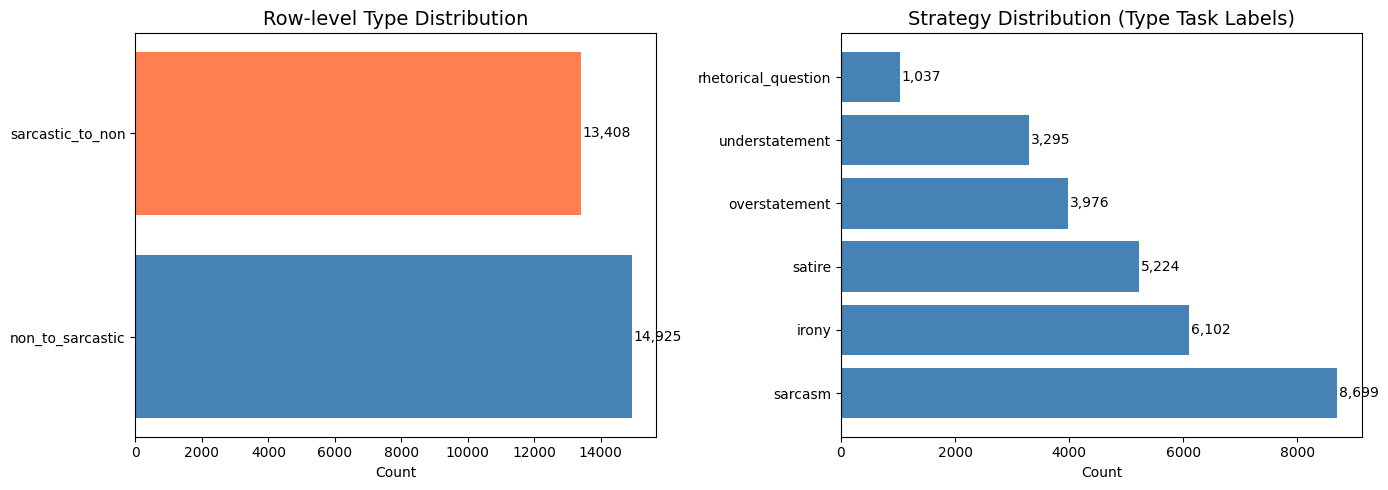

Saved: outputs/datasets/distributions.png


In [6]:
# ── Strategy distribution plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type dist
ax = axes[0]
labels, counts = zip(*sorted(type_counts.items(), key=lambda x: -x[1]))
ax.barh(labels, counts, color=["steelblue", "coral"])
ax.set_title("Row-level Type Distribution", fontsize=14)
ax.set_xlabel("Count")
for i, c in enumerate(counts):
    ax.text(c + 50, i, f"{c:,}", va="center")

# Strategy dist
ax = axes[1]
labels2, counts2 = zip(*sorted(strategy_counts.items(), key=lambda x: -x[1]))
ax.barh(labels2, counts2, color="steelblue")
ax.set_title("Strategy Distribution (Type Task Labels)", fontsize=14)
ax.set_xlabel("Count")
for i, c in enumerate(counts2):
    ax.text(c + 30, i, f"{c:,}", va="center")

plt.tight_layout()
plt.savefig(OUT_DATASETS / "distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/datasets/distributions.png")

## 3. Label Derivation and Dataset Expansion

In [7]:
from __future__ import annotations
from urllib.parse import urlparse


def normalize_url(url: str) -> str:
    """Lowercase and strip scheme/trailing slash for stable group IDs."""
    url = url.strip().lower()
    parsed = urlparse(url)
    normalized = (parsed.netloc + parsed.path).rstrip("/")
    return normalized if normalized else url


def derive_labels(raw_rows):
    """
    Expand each JSONL row into 2 samples (sarcastic + non-sarcastic).

    Rules:
      sarcastic_to_non -> original=sarcastic(1), generated=non-sarcastic(0)
      non_to_sarcastic -> original=non-sarcastic(0), generated=sarcastic(1)

    Returns binary_df, type_df
    """
    binary_records = []
    sample_id = 0

    for pair_id, row in enumerate(raw_rows):
        group_id   = normalize_url(row["article_link"]) if row["article_link"] else str(pair_id)
        row_type   = row["type"]
        strategy   = row["strategy"]
        model_used = row["model_used"]
        article    = row["article_link"]

        if row_type == "sarcastic_to_non":
            orig_label, orig_strat = 1, strategy
            gen_label,  gen_strat  = 0, None
        else:
            orig_label, orig_strat = 0, None
            gen_label,  gen_strat  = 1, strategy

        binary_records.append({
            "sample_id"    : sample_id,
            "pair_id"      : pair_id,
            "group_id"     : group_id,
            "text"         : row["original_headline"],
            "binary_label" : orig_label,
            "is_generated" : 0,
            "strategy"     : orig_strat,
            "source_type"  : row_type,
            "article_link" : article,
            "model_used"   : model_used,
        })
        sample_id += 1

        binary_records.append({
            "sample_id"    : sample_id,
            "pair_id"      : pair_id,
            "group_id"     : group_id,
            "text"         : row["generated_headline"],
            "binary_label" : gen_label,
            "is_generated" : 1,
            "strategy"     : gen_strat,
            "source_type"  : row_type,
            "article_link" : article,
            "model_used"   : model_used,
        })
        sample_id += 1

    binary_df = pd.DataFrame(binary_records)

    # Validate counts
    counts = binary_df["binary_label"].value_counts().to_dict()
    n_expected = len(raw_rows)
    n0 = int(counts.get(0, 0))
    n1 = int(counts.get(1, 0))
    if n0 != n_expected or n1 != n_expected:
        raise ValueError(
            f"Label count mismatch!\n"
            f"  Expected {n_expected} per class\n"
            f"  Got: sarcastic(1)={n1}, non-sarcastic(0)={n0}"
        )

    # Type dataset: sarcastic only
    type_df = binary_df[binary_df["binary_label"] == 1].copy()
    type_df = type_df.rename(columns={"strategy": "type_label"})
    type_df = type_df[["sample_id", "pair_id", "group_id", "text",
                        "type_label", "is_generated", "source_type",
                        "article_link", "model_used"]]

    missing = type_df["type_label"].isna().sum()
    if missing > 0:
        raise ValueError(f"{missing} sarcastic samples have no type_label!")

    return binary_df, type_df


binary_df, type_df = derive_labels(raw_rows)

print(f"Binary dataset : {len(binary_df):,} samples")
print(f"  sarcastic (1): {(binary_df['binary_label']==1).sum():,}")
print(f"  non-sarc  (0): {(binary_df['binary_label']==0).sum():,}")
print()
print(f"Type dataset   : {len(type_df):,} samples")
print(type_df["type_label"].value_counts().to_string())


Binary dataset : 56,666 samples
  sarcastic (1): 28,333
  non-sarc  (0): 28,333

Type dataset   : 28,333 samples
type_label
sarcasm                8699
irony                  6102
satire                 5224
overstatement          3976
understatement         3295
rhetorical_question    1037


In [8]:
# Save full datasets
binary_df.to_csv(OUT_DATASETS / "binary_dataset.csv", index=False)
type_df.to_csv(  OUT_DATASETS / "type_dataset.csv",   index=False)
print("Saved: outputs/datasets/binary_dataset.csv")
print("Saved: outputs/datasets/type_dataset.csv")

Saved: outputs/datasets/binary_dataset.csv
Saved: outputs/datasets/type_dataset.csv


## 4. Group-Aware Train / Val / Test Split

In [9]:
def group_aware_split(
    df: pd.DataFrame,
    group_col: str = "group_id",
    train_frac: float = 0.70,
    val_frac:   float = 0.15,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split df into train/val/test at the group level.
    All rows sharing a group_id go to exactly one split.
    """
    groups = df[group_col].unique().tolist()
    rng = np.random.default_rng(seed)
    rng.shuffle(groups)

    n = len(groups)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)

    train_groups = set(groups[:n_train])
    val_groups   = set(groups[n_train : n_train + n_val])
    test_groups  = set(groups[n_train + n_val :])

    train_df = df[df[group_col].isin(train_groups)].copy()
    val_df   = df[df[group_col].isin(val_groups)].copy()
    test_df  = df[df[group_col].isin(test_groups)].copy()

    # Sanity: no overlap
    assert train_groups.isdisjoint(val_groups),  "Train/val group overlap!"
    assert train_groups.isdisjoint(test_groups), "Train/test group overlap!"
    assert val_groups.isdisjoint(test_groups),   "Val/test group overlap!"

    return train_df, val_df, test_df


# ── Binary splits ─────────────────────────────────────────────────────────────
train_bin, val_bin, test_bin = group_aware_split(binary_df)

print("=== Binary splits ===")
for name, df in [("train", train_bin), ("val", val_bin), ("test", test_bin)]:
    dist = df["binary_label"].value_counts().to_dict()
    print(f"  {name:5s}: {len(df):,} samples | sarcastic={dist.get(1,0):,} non={dist.get(0,0):,}")

# ── Type splits ───────────────────────────────────────────────────────────────
train_type, val_type, test_type = group_aware_split(type_df)

print("\n=== Type splits ===")
for name, df in [("train", train_type), ("val", val_type), ("test", test_type)]:
    print(f"  {name:5s}: {len(df):,} samples")
    dist = df["type_label"].value_counts()
    for label, cnt in dist.items():
        print(f"    {label}: {cnt:,}")

=== Binary splits ===
  train: 39,666 samples | sarcastic=19,833 non=19,833
  val  : 8,500 samples | sarcastic=4,250 non=4,250
  test : 8,500 samples | sarcastic=4,250 non=4,250

=== Type splits ===
  train: 19,833 samples
    sarcasm: 6,091
    irony: 4,258
    satire: 3,644
    overstatement: 2,784
    understatement: 2,352
    rhetorical_question: 704
  val  : 4,250 samples
    sarcasm: 1,317
    irony: 942
    satire: 747
    overstatement: 600
    understatement: 487
    rhetorical_question: 157
  test : 4,250 samples
    sarcasm: 1,291
    irony: 902
    satire: 833
    overstatement: 592
    understatement: 456
    rhetorical_question: 176


In [10]:
# ── Verify no pair crosses split boundary ─────────────────────────────────────
# A pair_id should appear in at most ONE binary split
train_pairs = set(train_bin["pair_id"])
val_pairs   = set(val_bin["pair_id"])
test_pairs  = set(test_bin["pair_id"])

tv_overlap  = train_pairs & val_pairs
tt_overlap  = train_pairs & test_pairs
vt_overlap  = val_pairs   & test_pairs

print(f"Train/Val pair_id overlap  : {len(tv_overlap)} (must be 0)")
print(f"Train/Test pair_id overlap : {len(tt_overlap)} (must be 0)")
print(f"Val/Test pair_id overlap   : {len(vt_overlap)} (must be 0)")

assert len(tv_overlap) == 0 and len(tt_overlap) == 0 and len(vt_overlap) == 0, \
    "Leakage detected: pairs crossing split boundaries!"
print("\nLeakage check PASSED: No pair_id crosses split boundaries.")

Train/Val pair_id overlap  : 0 (must be 0)
Train/Test pair_id overlap : 0 (must be 0)
Val/Test pair_id overlap   : 0 (must be 0)

Leakage check PASSED: No pair_id crosses split boundaries.


In [11]:
# ── Save splits ───────────────────────────────────────────────────────────────
split_files = {
    "train_binary": train_bin,
    "val_binary"  : val_bin,
    "test_binary" : test_bin,
    "train_type"  : train_type,
    "val_type"    : val_type,
    "test_type"   : test_type,
}
for fname, df in split_files.items():
    path = OUT_SPLITS / f"{fname}.csv"
    df.to_csv(path, index=False)
    print(f"Saved: {path.relative_to(ROOT)}")

# Metadata
import json as _json
metadata = {
    "seed": SEED,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,
    "group_col": "group_id",
    "total_pairs": len(raw_rows),
    "binary": {
        "train": len(train_bin), "val": len(val_bin), "test": len(test_bin)
    },
    "type": {
        "train": len(train_type), "val": len(val_type), "test": len(test_type)
    },
}
with open(OUT_SPLITS / "split_metadata.json", "w") as f:
    _json.dump(metadata, f, indent=2)
print("\nSaved: outputs/splits/split_metadata.json")

Saved: outputs/splits/train_binary.csv
Saved: outputs/splits/val_binary.csv
Saved: outputs/splits/test_binary.csv
Saved: outputs/splits/train_type.csv
Saved: outputs/splits/val_type.csv
Saved: outputs/splits/test_type.csv

Saved: outputs/splits/split_metadata.json


## 5. Split Distribution Visualization

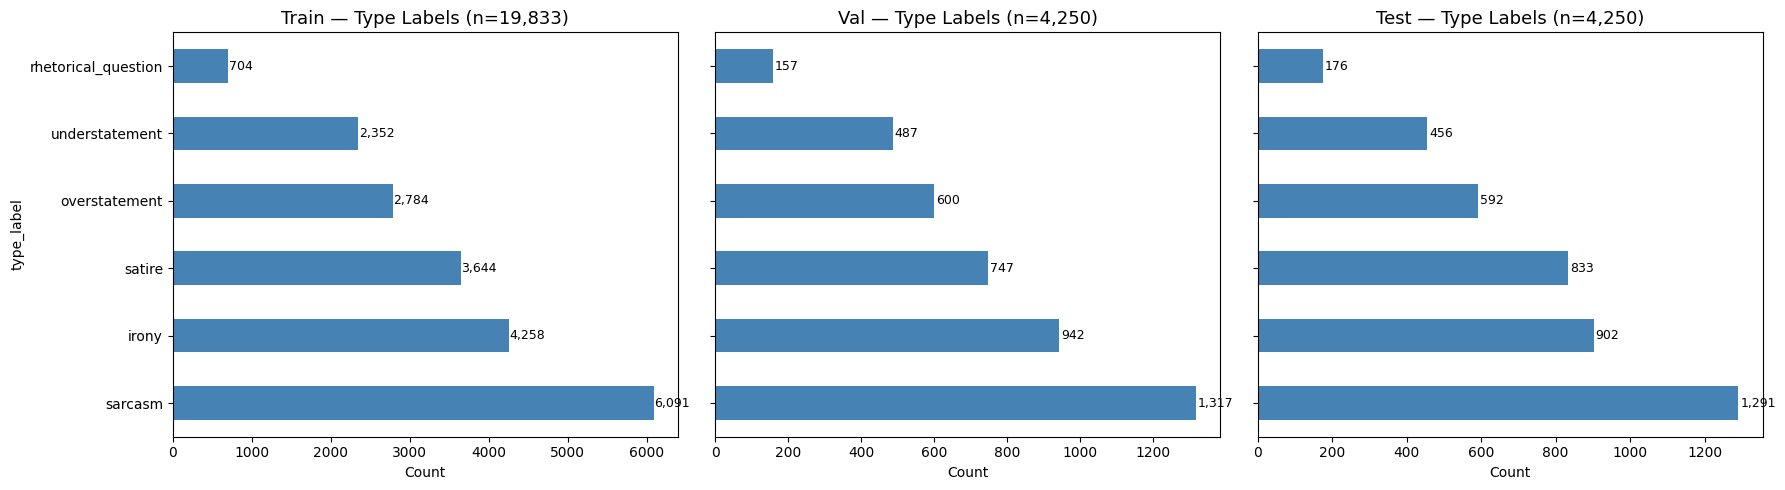

Saved: outputs/splits/type_split_distribution.png


In [12]:
# Type label distribution per split
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
split_dfs = [("Train", train_type), ("Val", val_type), ("Test", test_type)]

for ax, (name, df) in zip(axes, split_dfs):
    dist = df["type_label"].value_counts()
    dist.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{name} — Type Labels (n={len(df):,})", fontsize=13)
    ax.set_xlabel("Count")
    for i, (label, cnt) in enumerate(dist.items()):
        ax.text(cnt + 5, i, f"{cnt:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_SPLITS / "type_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/splits/type_split_distribution.png")

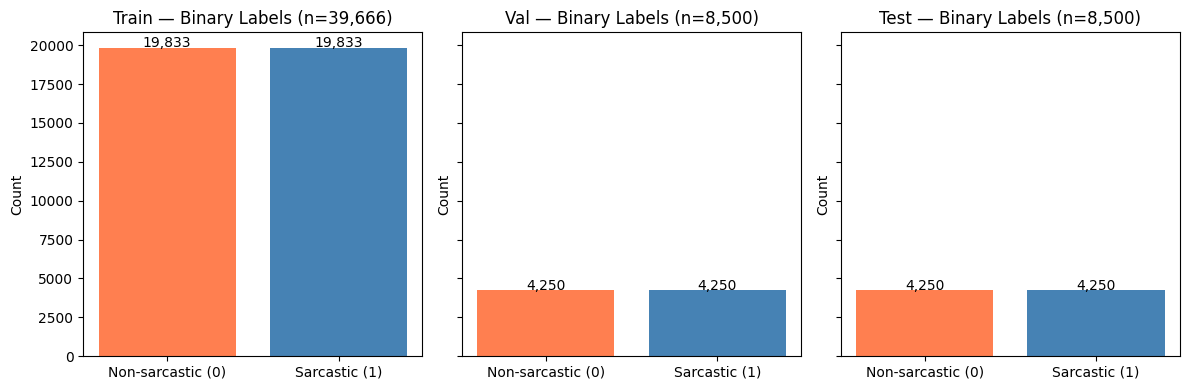

Saved: outputs/splits/binary_split_distribution.png


In [13]:
# Binary label distribution per split
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
split_dfs_bin = [("Train", train_bin), ("Val", val_bin), ("Test", test_bin)]

for ax, (name, df) in zip(axes, split_dfs_bin):
    dist = df["binary_label"].value_counts().sort_index()
    ax.bar(["Non-sarcastic (0)", "Sarcastic (1)"], dist.values, color=["coral", "steelblue"])
    ax.set_title(f"{name} — Binary Labels (n={len(df):,})", fontsize=12)
    ax.set_ylabel("Count")
    for i, v in enumerate(dist.values):
        ax.text(i, v + 20, f"{v:,}", ha="center")

plt.tight_layout()
plt.savefig(OUT_SPLITS / "binary_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/splits/binary_split_distribution.png")

In [14]:
print("\n=== Data Preparation Complete ===")
print(f"Binary dataset : {len(binary_df):,} samples (balanced)")
print(f"Type dataset   : {len(type_df):,} samples (imbalanced, 6 classes)")
print(f"Splits saved to: outputs/splits/")
print(f"Datasets saved : outputs/datasets/")
print("\nReady for classical baseline training (Notebooks 02 and 03).")


=== Data Preparation Complete ===
Binary dataset : 56,666 samples (balanced)
Type dataset   : 28,333 samples (imbalanced, 6 classes)
Splits saved to: outputs/splits/
Datasets saved : outputs/datasets/

Ready for classical baseline training (Notebooks 02 and 03).


---
# Part 2 — TF-IDF + Logistic Regression Baseline

# Notebook 02 — TF-IDF + Logistic Regression Baseline

**Purpose**: Train and evaluate TF-IDF + Logistic Regression pipelines for:
- Task A: Binary classification (sarcastic vs non-sarcastic)
- Task B: Sarcasm type classification (6-class)

**Prerequisite**: Run `01_data_preparation.ipynb` first.

**Outputs**:
- `outputs/classical/tfidf_lr/best_config_binary.json`
- `outputs/classical/tfidf_lr/best_config_type.json`
- `outputs/classical/tfidf_lr/metrics_binary.json`
- `outputs/classical/tfidf_lr/metrics_type.json`
- Predictions CSV + confusion matrices PNG

## Helper Functions

In [15]:
def load_splits(task: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load train/val/test CSVs for a given task ('binary' or 'type')."""
    train = pd.read_csv(SPLITS / f"train_{task}.csv")
    val   = pd.read_csv(SPLITS / f"val_{task}.csv")
    test  = pd.read_csv(SPLITS / f"test_{task}.csv")
    return train, val, test


def evaluate(
    model,
    X: list[str],
    y_true: list,
    label_names: list[str] | None = None,
    split_name: str = "",
) -> dict:
    """Compute classification metrics and return as dict."""
    y_pred = model.predict(X)
    metrics = {
        "split"           : split_name,
        "accuracy"        : accuracy_score(y_true, y_pred),
        "precision_macro" : precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro"    : recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro"        : f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted"     : f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "report"          : classification_report(y_true, y_pred, target_names=label_names,
                                                  zero_division=0, output_dict=True),
    }
    print(f"\n[{split_name}] Accuracy={metrics['accuracy']:.4f}  "
          f"Macro-F1={metrics['f1_macro']:.4f}  Weighted-F1={metrics['f1_weighted']:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    return metrics, y_pred


def save_confusion_matrix(
    y_true, y_pred, label_names: list[str], out_path: Path, title: str = ""
) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_names)))
    fig, ax = plt.subplots(figsize=(max(6, len(label_names)), max(5, len(label_names))))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_names, yticklabels=label_names, ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.relative_to(ROOT)}")


def save_predictions(
    df: pd.DataFrame, y_pred, label_col: str, out_path: Path
) -> None:
    out = df[["sample_id", "pair_id", "group_id", "text", label_col]].copy()
    out["predicted"] = y_pred
    out["correct"]   = (out[label_col] == out["predicted"]).astype(int)
    out.to_csv(out_path, index=False)
    print(f"Saved: {out_path.relative_to(ROOT)}")

## Task A — Binary Classification

In [16]:
# ── Load binary splits ────────────────────────────────────────────────────────
train_bin, val_bin, test_bin = load_splits("binary")

# Combine train+val for cross-validation, keep test for final eval
trainval_bin = pd.concat([train_bin, val_bin], ignore_index=True)

X_trainval = trainval_bin["text"].tolist()
y_trainval = trainval_bin["binary_label"].tolist()
groups_tv  = trainval_bin["group_id"].tolist()

X_train = train_bin["text"].tolist()
y_train = train_bin["binary_label"].tolist()

X_val   = val_bin["text"].tolist()
y_val   = val_bin["binary_label"].tolist()

X_test  = test_bin["text"].tolist()
y_test  = test_bin["binary_label"].tolist()

label_names_bin = ["non-sarcastic", "sarcastic"]

print(f"Train+Val: {len(X_trainval):,}  |  Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train+Val: 48,166  |  Train: 39,666  Val: 8,500  Test: 8,500


In [17]:
# ── Define pipeline and grid ──────────────────────────────────────────────────
pipe_bin = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, lowercase=True)),
    ("lr",    LogisticRegression(max_iter=1000, random_state=SEED, solver="lbfgs")),
])

param_grid_bin = {
    "tfidf__ngram_range" : [(1, 1), (1, 2)],
    "tfidf__min_df"      : [2, 3, 5],
    "tfidf__max_features": [None, 50_000],
    "lr__C"              : [0.1, 1.0, 3.0],
}

cv_bin = GroupKFold(n_splits=5)

gs_bin = GridSearchCV(
    pipe_bin, param_grid_bin,
    cv=cv_bin, scoring="f1_macro",
    n_jobs=-1, verbose=1, refit=True,
)

print(f"Grid size: {len(gs_bin.param_grid)} param combos → {5 * 2*3*2*3} fits")
print("Running grid search...")
gs_bin.fit(X_trainval, y_trainval, groups=groups_tv)

print(f"\nBest params  : {gs_bin.best_params_}")
print(f"Best CV F1   : {gs_bin.best_score_:.4f}")

Grid size: 4 param combos → 180 fits
Running grid search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params  : {'lr__C': 3.0, 'tfidf__max_features': None, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
Best CV F1   : 0.8143


In [18]:
# ── Save best config ──────────────────────────────────────────────────────────
best_cfg_bin = {"task": "binary", "model": "TF-IDF + LR", "seed": SEED,
                "best_params": gs_bin.best_params_, "cv_f1_macro": gs_bin.best_score_}
with open(OUT_TFIDF / "best_config_binary.json", "w") as f:
    json.dump(best_cfg_bin, f, indent=2)
print("Saved: outputs/classical/tfidf_lr/best_config_binary.json")

Saved: outputs/classical/tfidf_lr/best_config_binary.json


In [19]:
# ── Evaluate on val and test ──────────────────────────────────────────────────
best_bin = gs_bin.best_estimator_

val_metrics_bin,  y_val_pred_bin  = evaluate(best_bin, X_val,  y_val,  label_names_bin, "Val")
test_metrics_bin, y_test_pred_bin = evaluate(best_bin, X_test, y_test, label_names_bin, "Test")

all_metrics_bin = {"val": val_metrics_bin, "test": test_metrics_bin}

# Remove classification_report dict (too nested for JSON)
for split_m in all_metrics_bin.values():
    split_m.pop("report", None)

with open(OUT_TFIDF / "metrics_binary.json", "w") as f:
    json.dump(all_metrics_bin, f, indent=2)
print("Saved: outputs/classical/tfidf_lr/metrics_binary.json")


[Val] Accuracy=0.9186  Macro-F1=0.9186  Weighted-F1=0.9186
               precision    recall  f1-score   support

non-sarcastic       0.92      0.92      0.92      4250
    sarcastic       0.92      0.92      0.92      4250

     accuracy                           0.92      8500
    macro avg       0.92      0.92      0.92      8500
 weighted avg       0.92      0.92      0.92      8500


[Test] Accuracy=0.8189  Macro-F1=0.8189  Weighted-F1=0.8189
               precision    recall  f1-score   support

non-sarcastic       0.82      0.82      0.82      4250
    sarcastic       0.82      0.82      0.82      4250

     accuracy                           0.82      8500
    macro avg       0.82      0.82      0.82      8500
 weighted avg       0.82      0.82      0.82      8500

Saved: outputs/classical/tfidf_lr/metrics_binary.json


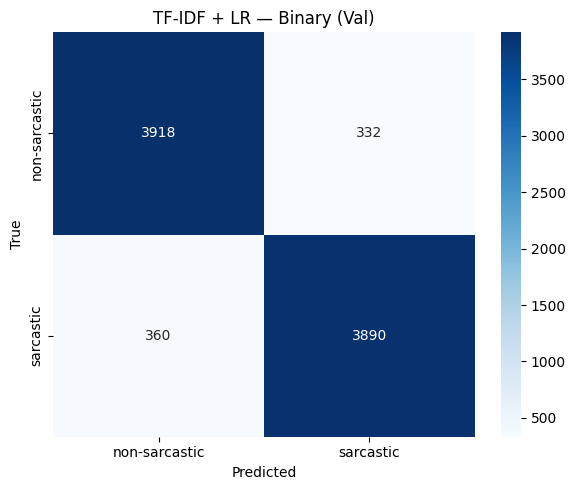

Saved: outputs/classical/tfidf_lr/confusion_matrix_binary_val.png


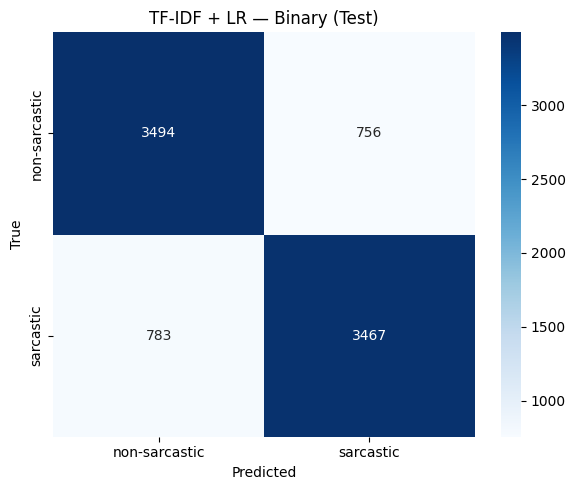

Saved: outputs/classical/tfidf_lr/confusion_matrix_binary_test.png


In [20]:
# ── Confusion matrices ────────────────────────────────────────────────────────
save_confusion_matrix(
    y_val, y_val_pred_bin, label_names_bin,
    OUT_TFIDF / "confusion_matrix_binary_val.png",
    "TF-IDF + LR — Binary (Val)"
)
save_confusion_matrix(
    y_test, y_test_pred_bin, label_names_bin,
    OUT_TFIDF / "confusion_matrix_binary_test.png",
    "TF-IDF + LR — Binary (Test)"
)

In [21]:
# ── Save predictions ──────────────────────────────────────────────────────────
save_predictions(val_bin,  y_val_pred_bin,  "binary_label", OUT_TFIDF / "predictions_val_binary.csv")
save_predictions(test_bin, y_test_pred_bin, "binary_label", OUT_TFIDF / "predictions_test_binary.csv")

Saved: outputs/classical/tfidf_lr/predictions_val_binary.csv
Saved: outputs/classical/tfidf_lr/predictions_test_binary.csv


In [22]:
# ── Feature importance: top discriminative terms ──────────────────────────────
tfidf_vocab = best_bin.named_steps["tfidf"].get_feature_names_out()
lr_coefs    = best_bin.named_steps["lr"].coef_[0]  # binary: shape (n_features,)

n_top = 20
top_pos_idx = np.argsort(lr_coefs)[-n_top:][::-1]
top_neg_idx = np.argsort(lr_coefs)[:n_top]

top_positive = [(tfidf_vocab[i], lr_coefs[i]) for i in top_pos_idx]
top_negative = [(tfidf_vocab[i], lr_coefs[i]) for i in top_neg_idx]

print("Top 20 sarcastic indicators (positive coef):")
for term, coef in top_positive:
    print(f"  {term:35s}  {coef:+.4f}")

print("\nTop 20 non-sarcastic indicators (negative coef):")
for term, coef in top_negative:
    print(f"  {term:35s}  {coef:+.4f}")

Top 20 sarcastic indicators (positive coef):
  because                              +22.1982
  finally                              +9.5906
  obviously                            +9.4255
  just                                 +9.2842
  so                                   +8.8645
  shocking                             +8.6605
  clearly                              +8.4488
  as if                                +8.3217
  proving                              +7.5734
  groundbreaking                       +7.5588
  nation                               +7.4750
  like                                 +7.1686
  nothing                              +6.5188
  shocker                              +6.5093
  never                                +6.4249
  totally                              +6.3599
  always                               +6.1954
  sure                                 +6.1921
  area                                 +6.0594
  who needs                            +6.0482

Top 20 non-sa

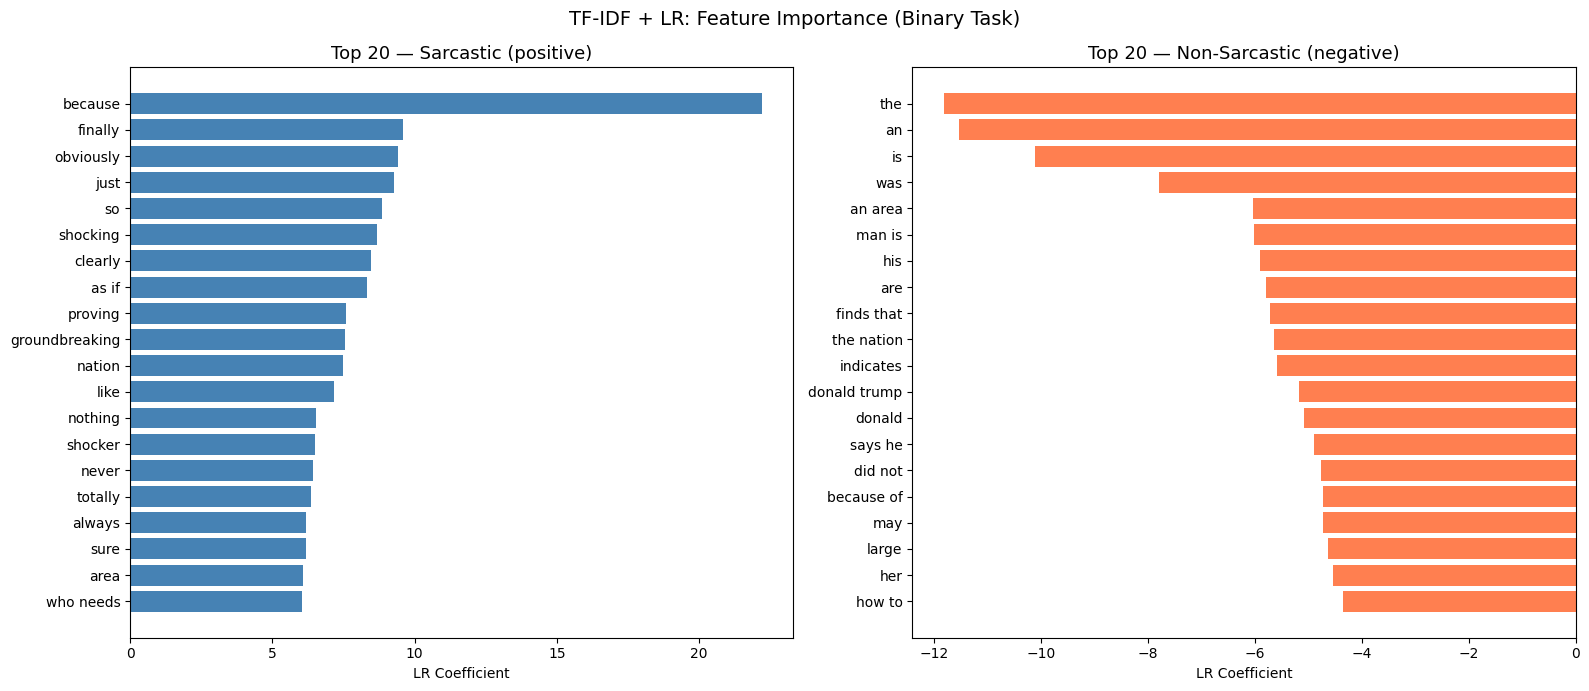

Saved: outputs/classical/tfidf_lr/feature_importance_binary.png


In [23]:
# ── Feature importance plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

terms_pos, coefs_pos = zip(*top_positive)
axes[0].barh(list(reversed(terms_pos)), list(reversed(coefs_pos)), color="steelblue")
axes[0].set_title("Top 20 — Sarcastic (positive)", fontsize=13)
axes[0].set_xlabel("LR Coefficient")

terms_neg, coefs_neg = zip(*top_negative)
axes[1].barh(list(reversed(terms_neg)), list(reversed(coefs_neg)), color="coral")
axes[1].set_title("Top 20 — Non-Sarcastic (negative)", fontsize=13)
axes[1].set_xlabel("LR Coefficient")

plt.suptitle("TF-IDF + LR: Feature Importance (Binary Task)", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_TFIDF / "feature_importance_binary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/classical/tfidf_lr/feature_importance_binary.png")

## Task B — Sarcasm Type Classification

In [24]:
# ── Load type splits ──────────────────────────────────────────────────────────
train_type, val_type, test_type = load_splits("type")

# Encode string labels to integers
STRATEGY_LABELS = sorted(train_type["type_label"].unique())
label2id = {lab: i for i, lab in enumerate(STRATEGY_LABELS)}
id2label = {i: lab for lab, i in label2id.items()}

def encode_labels(df: pd.DataFrame) -> list[int]:
    return [label2id[l] for l in df["type_label"]]

trainval_type = pd.concat([train_type, val_type], ignore_index=True)

X_trainval_t = trainval_type["text"].tolist()
y_trainval_t = encode_labels(trainval_type)
groups_tv_t  = trainval_type["group_id"].tolist()

X_train_t = train_type["text"].tolist()
y_train_t = encode_labels(train_type)
X_val_t   = val_type["text"].tolist()
y_val_t   = encode_labels(val_type)
X_test_t  = test_type["text"].tolist()
y_test_t  = encode_labels(test_type)

print(f"Strategies: {STRATEGY_LABELS}")
print(f"Train+Val: {len(X_trainval_t):,}  Train: {len(X_train_t):,}  Val: {len(X_val_t):,}  Test: {len(X_test_t):,}")

Strategies: ['irony', 'overstatement', 'rhetorical_question', 'sarcasm', 'satire', 'understatement']
Train+Val: 24,083  Train: 19,833  Val: 4,250  Test: 4,250


In [25]:
# ── Define pipeline and grid (with class_weight) ──────────────────────────────
pipe_type = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, lowercase=True)),
    ("lr",    LogisticRegression(max_iter=1000, random_state=SEED, solver="lbfgs",
                                 multi_class="auto")),
])

param_grid_type = {
    "tfidf__ngram_range" : [(1, 1), (1, 2)],
    "tfidf__min_df"      : [2, 3, 5],
    "tfidf__max_features": [None, 50_000],
    "lr__C"              : [0.1, 1.0, 3.0],
    "lr__class_weight"   : [None, "balanced"],
}

cv_type = GroupKFold(n_splits=5)

gs_type = GridSearchCV(
    pipe_type, param_grid_type,
    cv=cv_type, scoring="f1_macro",
    n_jobs=-1, verbose=1, refit=True,
)

print("Running grid search for type task...")
gs_type.fit(X_trainval_t, y_trainval_t, groups=groups_tv_t)

print(f"\nBest params  : {gs_type.best_params_}")
print(f"Best CV F1   : {gs_type.best_score_:.4f}")

Running grid search for type task...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best params  : {'lr__C': 3.0, 'lr__class_weight': 'balanced', 'tfidf__max_features': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV F1   : 0.3848


In [26]:
# ── Save best config ──────────────────────────────────────────────────────────
best_cfg_type = {"task": "type", "model": "TF-IDF + LR", "seed": SEED,
                 "label_names": STRATEGY_LABELS, "label2id": label2id,
                 "best_params": gs_type.best_params_, "cv_f1_macro": gs_type.best_score_}
with open(OUT_TFIDF / "best_config_type.json", "w") as f:
    json.dump(best_cfg_type, f, indent=2)
print("Saved: outputs/classical/tfidf_lr/best_config_type.json")

Saved: outputs/classical/tfidf_lr/best_config_type.json


In [27]:
# ── Evaluate on val and test ──────────────────────────────────────────────────
best_type = gs_type.best_estimator_

val_metrics_type,  y_val_pred_type  = evaluate(best_type, X_val_t,  y_val_t,  STRATEGY_LABELS, "Val")
test_metrics_type, y_test_pred_type = evaluate(best_type, X_test_t, y_test_t, STRATEGY_LABELS, "Test")

all_metrics_type = {"val": val_metrics_type, "test": test_metrics_type}
for split_m in all_metrics_type.values():
    split_m.pop("report", None)

with open(OUT_TFIDF / "metrics_type.json", "w") as f:
    json.dump(all_metrics_type, f, indent=2)
print("Saved: outputs/classical/tfidf_lr/metrics_type.json")


[Val] Accuracy=0.8979  Macro-F1=0.8991  Weighted-F1=0.8973
                     precision    recall  f1-score   support

              irony       0.92      0.87      0.90       942
      overstatement       0.88      0.97      0.92       600
rhetorical_question       0.79      1.00      0.88       157
            sarcasm       0.94      0.83      0.88      1317
             satire       0.88      0.92      0.90       747
     understatement       0.85      0.98      0.91       487

           accuracy                           0.90      4250
          macro avg       0.88      0.93      0.90      4250
       weighted avg       0.90      0.90      0.90      4250


[Test] Accuracy=0.3953  Macro-F1=0.4047  Weighted-F1=0.3942
                     precision    recall  f1-score   support

              irony       0.33      0.29      0.31       902
      overstatement       0.38      0.43      0.40       592
rhetorical_question       0.42      0.61      0.50       176
            sarcasm  

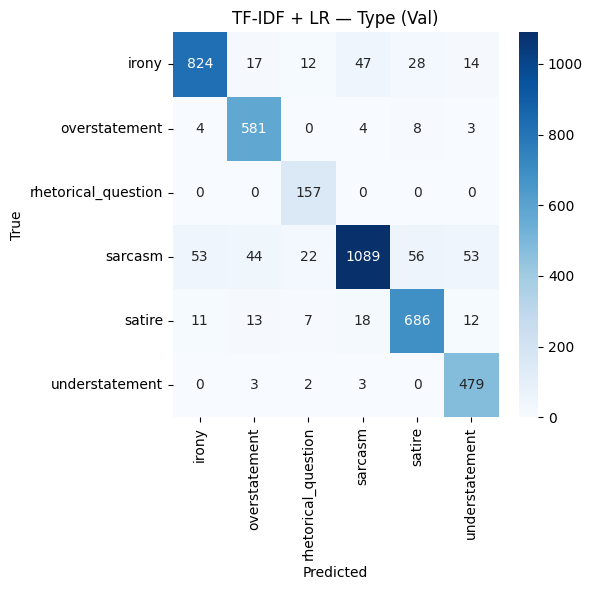

Saved: outputs/classical/tfidf_lr/confusion_matrix_type_val.png


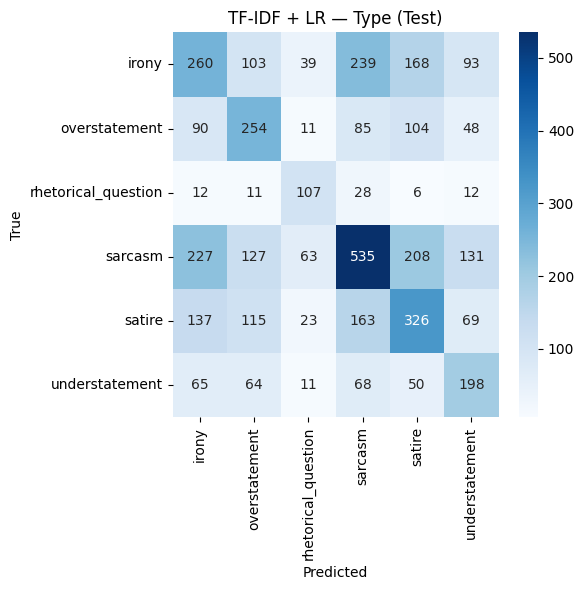

Saved: outputs/classical/tfidf_lr/confusion_matrix_type_test.png


In [28]:
# ── Confusion matrices ────────────────────────────────────────────────────────
save_confusion_matrix(
    y_val_t, y_val_pred_type, STRATEGY_LABELS,
    OUT_TFIDF / "confusion_matrix_type_val.png",
    "TF-IDF + LR — Type (Val)"
)
save_confusion_matrix(
    y_test_t, y_test_pred_type, STRATEGY_LABELS,
    OUT_TFIDF / "confusion_matrix_type_test.png",
    "TF-IDF + LR — Type (Test)"
)

In [29]:
# ── Save predictions ──────────────────────────────────────────────────────────
# Decode integer predictions back to string labels
val_type_copy  = val_type.copy();  val_type_copy["type_label"]  = y_val_t
test_type_copy = test_type.copy(); test_type_copy["type_label"] = y_test_t

val_type_copy["predicted_id"]    = y_val_pred_type
val_type_copy["predicted_label"] = [id2label[i] for i in y_val_pred_type]
val_type_copy["true_label"]      = [id2label[i] for i in y_val_t]
val_type_copy["correct"]         = (val_type_copy["type_label"] == val_type_copy["predicted_id"]).astype(int)

test_type_copy["predicted_id"]    = y_test_pred_type
test_type_copy["predicted_label"] = [id2label[i] for i in y_test_pred_type]
test_type_copy["true_label"]      = [id2label[i] for i in y_test_t]
test_type_copy["correct"]         = (test_type_copy["type_label"] == test_type_copy["predicted_id"]).astype(int)

val_type_copy.to_csv( OUT_TFIDF / "predictions_val_type.csv",  index=False)
test_type_copy.to_csv(OUT_TFIDF / "predictions_test_type.csv", index=False)
print("Saved predictions_val_type.csv and predictions_test_type.csv")

Saved predictions_val_type.csv and predictions_test_type.csv


## Char N-gram Variant (Optional)

In [30]:
# Char n-gram model for binary task (stylistic cues)
pipe_char = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                              sublinear_tf=True, lowercase=True, max_features=50_000)),
    ("lr",    LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)),
])

param_grid_char = {"lr__C": [0.1, 1.0, 3.0]}
gs_char = GridSearchCV(pipe_char, param_grid_char, cv=GroupKFold(5),
                       scoring="f1_macro", n_jobs=-1)
gs_char.fit(X_trainval, y_trainval, groups=groups_tv)

print(f"Char n-gram best C      : {gs_char.best_params_}")
print(f"Char n-gram best CV F1  : {gs_char.best_score_:.4f}")
print(f"Word n-gram best CV F1  : {gs_bin.best_score_:.4f}")
print()
char_metrics, _ = evaluate(gs_char.best_estimator_, X_test, y_test, label_names_bin, "Test (char)")

Char n-gram best C      : {'lr__C': 3.0}
Char n-gram best CV F1  : 0.8308
Word n-gram best CV F1  : 0.8143


[Test (char)] Accuracy=0.8289  Macro-F1=0.8289  Weighted-F1=0.8289
               precision    recall  f1-score   support

non-sarcastic       0.82      0.84      0.83      4250
    sarcastic       0.84      0.82      0.83      4250

     accuracy                           0.83      8500
    macro avg       0.83      0.83      0.83      8500
 weighted avg       0.83      0.83      0.83      8500



## Summary

In [31]:
print("====== TF-IDF + LR RESULTS SUMMARY ======")
print()
print("Task A — Binary Classification (Test Set):")
print(f"  Accuracy        : {test_metrics_bin['accuracy']:.4f}")
print(f"  Macro-F1        : {test_metrics_bin['f1_macro']:.4f}")
print(f"  Weighted-F1     : {test_metrics_bin['f1_weighted']:.4f}")
print()
print("Task B — Type Classification (Test Set):")
print(f"  Accuracy        : {test_metrics_type['accuracy']:.4f}")
print(f"  Macro-F1        : {test_metrics_type['f1_macro']:.4f}")
print(f"  Weighted-F1     : {test_metrics_type['f1_weighted']:.4f}")
print()
print("Best hyperparameters:")
print("  Binary:", gs_bin.best_params_)
print("  Type:  ", gs_type.best_params_)

====== TF-IDF + LR RESULTS SUMMARY ======

Task A — Binary Classification (Test Set):
  Accuracy        : 0.8189
  Macro-F1        : 0.8189
  Weighted-F1     : 0.8189

Task B — Type Classification (Test Set):
  Accuracy        : 0.3953
  Macro-F1        : 0.4047
  Weighted-F1     : 0.3942

Best hyperparameters:
  Binary: {'lr__C': 3.0, 'tfidf__max_features': None, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
  Type:   {'lr__C': 3.0, 'lr__class_weight': 'balanced', 'tfidf__max_features': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}


---
# Part 3 — Naive Bayes Baseline

# Notebook 03 — Naive Bayes Baseline

**Purpose**: Train and evaluate Naive Bayes classifiers for:
- Task A: Binary classification (sarcastic vs non-sarcastic)
- Task B: Sarcasm type classification (6-class)

Compares:
- `CountVectorizer + MultinomialNB`
- `TfidfVectorizer + MultinomialNB`
- `CountVectorizer + ComplementNB` (for imbalanced type task)

**Prerequisite**: Run `01_data_preparation.ipynb` first.

**Outputs** in `outputs/classical/naive_bayes/`

## Helper Functions

In [32]:
def load_splits(task: str):
    train = pd.read_csv(SPLITS / f"train_{task}.csv")
    val   = pd.read_csv(SPLITS / f"val_{task}.csv")
    test  = pd.read_csv(SPLITS / f"test_{task}.csv")
    return train, val, test


def evaluate(model, X, y_true, label_names=None, split_name=""):
    y_pred = model.predict(X)
    metrics = {
        "split"           : split_name,
        "accuracy"        : accuracy_score(y_true, y_pred),
        "precision_macro" : precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro"    : recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro"        : f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted"     : f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    print(f"[{split_name}] Accuracy={metrics['accuracy']:.4f}  "
          f"Macro-F1={metrics['f1_macro']:.4f}  Weighted-F1={metrics['f1_weighted']:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    return metrics, y_pred


def save_confusion_matrix(y_true, y_pred, label_names, out_path, title=""):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_names)))
    fig, ax = plt.subplots(figsize=(max(6, len(label_names)), max(5, len(label_names))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.relative_to(ROOT)}")


def run_nb_grid(
    vectorizer_cls, nb_cls, param_grid: dict,
    X_trainval, y_trainval, groups_tv,
    name: str
) -> GridSearchCV:
    """Run a grid search for a given vectorizer + NB combination."""
    pipe = Pipeline([
        ("vec", vectorizer_cls(lowercase=True)),
        ("nb",  nb_cls()),
    ])
    gs = GridSearchCV(
        pipe, param_grid, cv=GroupKFold(5),
        scoring="f1_macro", n_jobs=-1, verbose=0, refit=True
    )
    gs.fit(X_trainval, y_trainval, groups=groups_tv)
    print(f"{name:50s}  CV F1={gs.best_score_:.4f}  params={gs.best_params_}")
    return gs

## Task A — Binary Classification

In [33]:
train_bin, val_bin, test_bin = load_splits("binary")
trainval_bin = pd.concat([train_bin, val_bin], ignore_index=True)

X_tv   = trainval_bin["text"].tolist()
y_tv   = trainval_bin["binary_label"].tolist()
grp_tv = trainval_bin["group_id"].tolist()

X_val  = val_bin["text"].tolist();  y_val  = val_bin["binary_label"].tolist()
X_test = test_bin["text"].tolist(); y_test = test_bin["binary_label"].tolist()

label_names_bin = ["non-sarcastic", "sarcastic"]

print(f"Train+Val: {len(X_tv):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train+Val: 48,166  Val: 8,500  Test: 8,500


In [34]:
# ── Shared grid parameters ────────────────────────────────────────────────────
BASE_GRID = {
    "vec__ngram_range": [(1, 1), (1, 2)],
    "vec__min_df"     : [2, 3, 5],
    "nb__alpha"       : [0.1, 0.5, 1.0],
}

print("=== Binary: Comparing Vectorizer + NB Combinations ===")

gs_count_mnb_bin = run_nb_grid(
    CountVectorizer, MultinomialNB, BASE_GRID,
    X_tv, y_tv, grp_tv,
    "CountVectorizer + MultinomialNB"
)

gs_tfidf_mnb_bin = run_nb_grid(
    TfidfVectorizer, MultinomialNB, BASE_GRID,
    X_tv, y_tv, grp_tv,
    "TfidfVectorizer + MultinomialNB"
)

gs_count_cnb_bin = run_nb_grid(
    CountVectorizer, ComplementNB, BASE_GRID,
    X_tv, y_tv, grp_tv,
    "CountVectorizer + ComplementNB"
)

=== Binary: Comparing Vectorizer + NB Combinations ===
CountVectorizer + MultinomialNB                     CV F1=0.7857  params={'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
TfidfVectorizer + MultinomialNB                     CV F1=0.7896  params={'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
CountVectorizer + ComplementNB                      CV F1=0.7857  params={'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}


In [35]:
# ── Select best binary model ──────────────────────────────────────────────────
candidates_bin = [
    ("CountVec+MultinomialNB", gs_count_mnb_bin),
    ("TfidfVec+MultinomialNB", gs_tfidf_mnb_bin),
    ("CountVec+ComplementNB",  gs_count_cnb_bin),
]

best_name_bin, best_gs_bin = max(candidates_bin, key=lambda x: x[1].best_score_)
print(f"\nBest binary NB model: {best_name_bin} (CV F1={best_gs_bin.best_score_:.4f})")

# Comparison table
comp_df = pd.DataFrame([
    {"model": name, "cv_f1_macro": gs.best_score_, "best_params": str(gs.best_params_)}
    for name, gs in candidates_bin
])
print("\nComparison table:")
print(comp_df.to_string(index=False))


Best binary NB model: TfidfVec+MultinomialNB (CV F1=0.7896)

Comparison table:
                 model  cv_f1_macro                                                      best_params
CountVec+MultinomialNB     0.785667 {'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
TfidfVec+MultinomialNB     0.789619 {'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
 CountVec+ComplementNB     0.785667 {'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}


In [36]:
# ── Evaluate best model ───────────────────────────────────────────────────────
best_model_bin = best_gs_bin.best_estimator_

val_m_bin,  y_val_pred_bin  = evaluate(best_model_bin, X_val,  y_val,  label_names_bin, "Val")
test_m_bin, y_test_pred_bin = evaluate(best_model_bin, X_test, y_test, label_names_bin, "Test")

# Also evaluate all three models on test for comparison
print("\n--- All models on Test ---")
all_test_results_bin = []
for name, gs in candidates_bin:
    y_pred_t = gs.best_estimator_.predict(X_test)
    f1 = f1_score(y_test, y_pred_t, average="macro")
    acc = accuracy_score(y_test, y_pred_t)
    all_test_results_bin.append({"model": name, "accuracy": acc, "f1_macro": f1})
    print(f"  {name:40s}: acc={acc:.4f}  macro-F1={f1:.4f}")

[Val] Accuracy=0.8826  Macro-F1=0.8826  Weighted-F1=0.8826
               precision    recall  f1-score   support

non-sarcastic       0.89      0.87      0.88      4250
    sarcastic       0.87      0.90      0.88      4250

     accuracy                           0.88      8500
    macro avg       0.88      0.88      0.88      8500
 weighted avg       0.88      0.88      0.88      8500

[Test] Accuracy=0.7905  Macro-F1=0.7902  Weighted-F1=0.7902
               precision    recall  f1-score   support

non-sarcastic       0.81      0.76      0.78      4250
    sarcastic       0.77      0.83      0.80      4250

     accuracy                           0.79      8500
    macro avg       0.79      0.79      0.79      8500
 weighted avg       0.79      0.79      0.79      8500


--- All models on Test ---
  CountVec+MultinomialNB                  : acc=0.7887  macro-F1=0.7886
  TfidfVec+MultinomialNB                  : acc=0.7905  macro-F1=0.7902
  CountVec+ComplementNB                   :

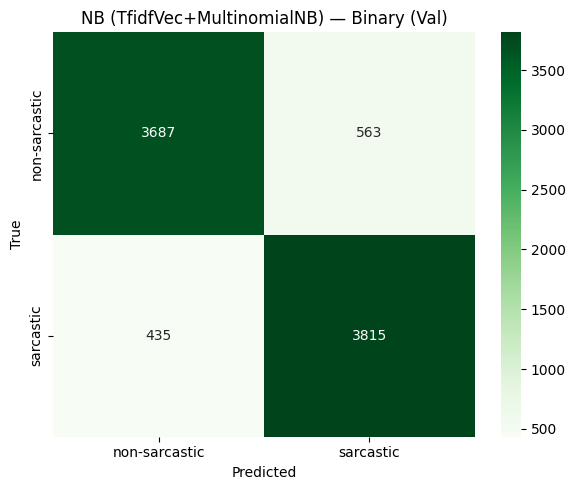

Saved: outputs/classical/naive_bayes/confusion_matrix_binary_val.png


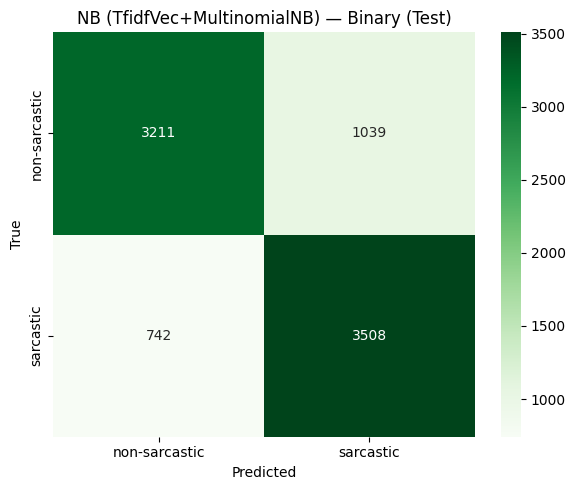

Saved: outputs/classical/naive_bayes/confusion_matrix_binary_test.png
All binary artifacts saved.


In [37]:
# ── Save binary results ───────────────────────────────────────────────────────
cfg_bin = {
    "task": "binary", "best_model": best_name_bin,
    "best_params": best_gs_bin.best_params_, "cv_f1_macro": best_gs_bin.best_score_,
    "all_candidates": [
        {"model": name, "cv_f1_macro": gs.best_score_, "params": gs.best_params_}
        for name, gs in candidates_bin
    ]
}
with open(OUT_NB / "best_config_binary.json", "w") as f:
    json.dump(cfg_bin, f, indent=2)

all_m_bin = {"val": val_m_bin, "test": test_m_bin,
             "all_test_comparison": all_test_results_bin}
with open(OUT_NB / "metrics_binary.json", "w") as f:
    json.dump(all_m_bin, f, indent=2)

save_confusion_matrix(
    y_val, y_val_pred_bin, label_names_bin,
    OUT_NB / "confusion_matrix_binary_val.png",
    f"NB ({best_name_bin}) — Binary (Val)"
)
save_confusion_matrix(
    y_test, y_test_pred_bin, label_names_bin,
    OUT_NB / "confusion_matrix_binary_test.png",
    f"NB ({best_name_bin}) — Binary (Test)"
)

# Predictions
pred_val_bin = val_bin.copy()
pred_val_bin["predicted"] = y_val_pred_bin
pred_val_bin["correct"]   = (pred_val_bin["binary_label"] == pred_val_bin["predicted"]).astype(int)
pred_val_bin.to_csv(OUT_NB / "predictions_val_binary.csv", index=False)

pred_test_bin = test_bin.copy()
pred_test_bin["predicted"] = y_test_pred_bin
pred_test_bin["correct"]   = (pred_test_bin["binary_label"] == pred_test_bin["predicted"]).astype(int)
pred_test_bin.to_csv(OUT_NB / "predictions_test_binary.csv", index=False)

print("All binary artifacts saved.")

## Task B — Sarcasm Type Classification

In [38]:
train_type, val_type, test_type = load_splits("type")

STRATEGY_LABELS = sorted(train_type["type_label"].unique())
label2id = {lab: i for i, lab in enumerate(STRATEGY_LABELS)}
id2label = {i: lab for lab, i in label2id.items()}

def enc(df): return [label2id[l] for l in df["type_label"]]

trainval_type = pd.concat([train_type, val_type], ignore_index=True)
X_tv_t   = trainval_type["text"].tolist()
y_tv_t   = enc(trainval_type)
grp_tv_t = trainval_type["group_id"].tolist()

X_val_t  = val_type["text"].tolist();  y_val_t  = enc(val_type)
X_test_t = test_type["text"].tolist(); y_test_t = enc(test_type)

print(f"Strategies: {STRATEGY_LABELS}")
print(f"Train+Val: {len(X_tv_t):,}  Val: {len(X_val_t):,}  Test: {len(X_test_t):,}")

Strategies: ['irony', 'overstatement', 'rhetorical_question', 'sarcasm', 'satire', 'understatement']
Train+Val: 24,083  Val: 4,250  Test: 4,250


In [39]:
print("=== Type: Comparing Vectorizer + NB Combinations ===")

gs_count_mnb_type = run_nb_grid(
    CountVectorizer, MultinomialNB, BASE_GRID,
    X_tv_t, y_tv_t, grp_tv_t,
    "CountVectorizer + MultinomialNB"
)

gs_tfidf_mnb_type = run_nb_grid(
    TfidfVectorizer, MultinomialNB, BASE_GRID,
    X_tv_t, y_tv_t, grp_tv_t,
    "TfidfVectorizer + MultinomialNB"
)

gs_count_cnb_type = run_nb_grid(
    CountVectorizer, ComplementNB, BASE_GRID,
    X_tv_t, y_tv_t, grp_tv_t,
    "CountVectorizer + ComplementNB  (for imbalance)"
)

=== Type: Comparing Vectorizer + NB Combinations ===
CountVectorizer + MultinomialNB                     CV F1=0.3813  params={'nb__alpha': 0.5, 'vec__min_df': 3, 'vec__ngram_range': (1, 2)}
TfidfVectorizer + MultinomialNB                     CV F1=0.3432  params={'nb__alpha': 0.1, 'vec__min_df': 3, 'vec__ngram_range': (1, 2)}
CountVectorizer + ComplementNB  (for imbalance)     CV F1=0.3786  params={'nb__alpha': 1.0, 'vec__min_df': 3, 'vec__ngram_range': (1, 2)}


In [40]:
candidates_type = [
    ("CountVec+MultinomialNB", gs_count_mnb_type),
    ("TfidfVec+MultinomialNB", gs_tfidf_mnb_type),
    ("CountVec+ComplementNB",  gs_count_cnb_type),
]

best_name_type, best_gs_type = max(candidates_type, key=lambda x: x[1].best_score_)
print(f"Best type NB model: {best_name_type} (CV F1={best_gs_type.best_score_:.4f})")

print("\n--- All models on Test (Type Task) ---")
all_test_results_type = []
for name, gs in candidates_type:
    y_pred_t = gs.best_estimator_.predict(X_test_t)
    f1  = f1_score(y_test_t, y_pred_t, average="macro")
    acc = accuracy_score(y_test_t, y_pred_t)
    all_test_results_type.append({"model": name, "accuracy": acc, "f1_macro": f1})
    print(f"  {name:40s}: acc={acc:.4f}  macro-F1={f1:.4f}")

Best type NB model: CountVec+MultinomialNB (CV F1=0.3813)

--- All models on Test (Type Task) ---
  CountVec+MultinomialNB                  : acc=0.3953  macro-F1=0.3953
  TfidfVec+MultinomialNB                  : acc=0.3800  macro-F1=0.3450
  CountVec+ComplementNB                   : acc=0.3875  macro-F1=0.3880


[Val] Accuracy=0.7694  Macro-F1=0.7744  Weighted-F1=0.7693
                     precision    recall  f1-score   support

              irony       0.80      0.72      0.76       942
      overstatement       0.75      0.80      0.77       600
rhetorical_question       0.78      0.88      0.83       157
            sarcasm       0.79      0.78      0.79      1317
             satire       0.73      0.77      0.75       747
     understatement       0.75      0.75      0.75       487

           accuracy                           0.77      4250
          macro avg       0.77      0.78      0.77      4250
       weighted avg       0.77      0.77      0.77      4250

[Test] Accuracy=0.3953  Macro-F1=0.3953  Weighted-F1=0.3929
                     precision    recall  f1-score   support

              irony       0.32      0.29      0.30       902
      overstatement       0.39      0.40      0.39       592
rhetorical_question       0.52      0.41      0.46       176
            sarcasm    

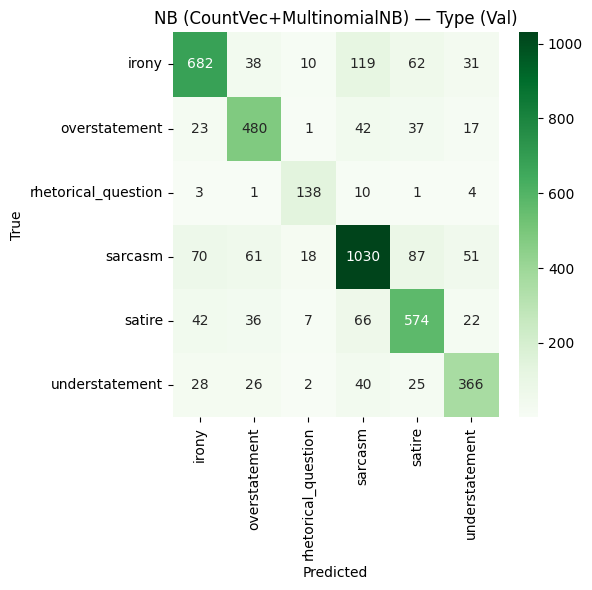

Saved: outputs/classical/naive_bayes/confusion_matrix_type_val.png


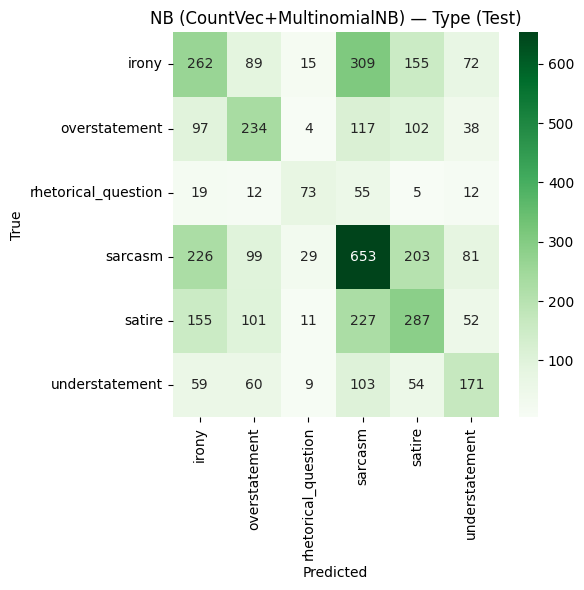

Saved: outputs/classical/naive_bayes/confusion_matrix_type_test.png
All type artifacts saved.


In [41]:
best_model_type = best_gs_type.best_estimator_

val_m_type,  y_val_pred_type  = evaluate(best_model_type, X_val_t,  y_val_t,  STRATEGY_LABELS, "Val")
test_m_type, y_test_pred_type = evaluate(best_model_type, X_test_t, y_test_t, STRATEGY_LABELS, "Test")

# Save
cfg_type = {
    "task": "type", "best_model": best_name_type,
    "label_names": STRATEGY_LABELS, "label2id": label2id,
    "best_params": best_gs_type.best_params_, "cv_f1_macro": best_gs_type.best_score_,
}
with open(OUT_NB / "best_config_type.json", "w") as f:
    json.dump(cfg_type, f, indent=2)

all_m_type = {"val": val_m_type, "test": test_m_type,
              "all_test_comparison": all_test_results_type}
with open(OUT_NB / "metrics_type.json", "w") as f:
    json.dump(all_m_type, f, indent=2)

save_confusion_matrix(
    y_val_t, y_val_pred_type, STRATEGY_LABELS,
    OUT_NB / "confusion_matrix_type_val.png",
    f"NB ({best_name_type}) — Type (Val)"
)
save_confusion_matrix(
    y_test_t, y_test_pred_type, STRATEGY_LABELS,
    OUT_NB / "confusion_matrix_type_test.png",
    f"NB ({best_name_type}) — Type (Test)"
)

# Predictions with string labels
pred_val_type  = val_type.copy()
pred_test_type = test_type.copy()
for df, y_pred, y_true in [(pred_val_type, y_val_pred_type, y_val_t),
                            (pred_test_type, y_test_pred_type, y_test_t)]:
    df["predicted_label"] = [id2label[i] for i in y_pred]
    df["true_label"]      = [id2label[i] for i in y_true]
    df["correct"]         = (df["type_label"] == df["predicted_label"]).astype(int)

pred_val_type.to_csv( OUT_NB / "predictions_val_type.csv",  index=False)
pred_test_type.to_csv(OUT_NB / "predictions_test_type.csv", index=False)

print("All type artifacts saved.")

## Error Examples

In [42]:
# ── Binary error examples ─────────────────────────────────────────────────────
err_bin = pred_test_bin[pred_test_bin["correct"] == 0].copy()
fp_bin  = err_bin[err_bin["binary_label"] == 0].head(10)  # predicted sarcastic, actually not
fn_bin  = err_bin[err_bin["binary_label"] == 1].head(10)  # predicted not-sarcastic, actually sarcastic

print(f"Binary errors on test: {len(err_bin)} total")
print(f"  False Positives (predicted sarcastic, actually not): {len(err_bin[err_bin['binary_label']==0])}")
print(f"  False Negatives (predicted not-sarcastic, actually sarcastic): {len(err_bin[err_bin['binary_label']==1])}")
print("\n--- Sample FP ---")
for _, row in fp_bin.iterrows():
    print(f"  [True=0, Pred=1] {row['text'][:100]}")
print("\n--- Sample FN ---")
for _, row in fn_bin.iterrows():
    print(f"  [True=1, Pred=0] {row['text'][:100]}")

Binary errors on test: 1781 total
  False Positives (predicted sarcastic, actually not): 1039
  False Negatives (predicted not-sarcastic, actually sarcastic): 742

--- Sample FP ---
  [True=0, Pred=1] Probability researchers note a coincidence where three coworkers wear the same shirt color.
  [True=0, Pred=1] The global-warming crisis contributed to a delightful mid-February afternoon.
  [True=0, Pred=1] Signs for the upcoming road section make it sound formidable or exciting.
  [True=0, Pred=1] A father recounts how he saved $4.27 through quick thinking.
  [True=0, Pred=1] The wedding album begins with a photo of two acorns floating in a glass of water.
  [True=0, Pred=1] A governor is too embarrassed to say which state he leads.
  [True=0, Pred=1] A man who plays devil's advocate may actually just want to be disagreeable.
  [True=0, Pred=1] Area dad watched a show about bigfoot last night.
  [True=0, Pred=1] Coroner's report cites systemic issues in Alton Sterling's death.
  [True=0

In [43]:
# ── Type error examples ───────────────────────────────────────────────────────
err_type = pred_test_type[pred_test_type["correct"] == 0].copy()
print(f"Type errors on test: {len(err_type)} total")
print("\nConfusion pairs (true → predicted):")
conf_pairs = err_type.groupby(["type_label", "predicted_label"]).size().sort_values(ascending=False).head(10)
print(conf_pairs.to_string())

Type errors on test: 2570 total

Confusion pairs (true → predicted):
type_label      predicted_label
irony           sarcasm            309
satire          sarcasm            227
sarcasm         irony              226
                satire             203
satire          irony              155
irony           satire             155
overstatement   sarcasm            117
understatement  sarcasm            103
overstatement   satire             102
satire          overstatement      101


## Summary

In [44]:
print("====== NAIVE BAYES RESULTS SUMMARY ======")
print()
print("Task A — Binary (Test):")
print(f"  Best model    : {best_name_bin}")
print(f"  Accuracy      : {test_m_bin['accuracy']:.4f}")
print(f"  Macro-F1      : {test_m_bin['f1_macro']:.4f}")
print(f"  Weighted-F1   : {test_m_bin['f1_weighted']:.4f}")
print()
print("Task B — Type (Test):")
print(f"  Best model    : {best_name_type}")
print(f"  Accuracy      : {test_m_type['accuracy']:.4f}")
print(f"  Macro-F1      : {test_m_type['f1_macro']:.4f}")
print(f"  Weighted-F1   : {test_m_type['f1_weighted']:.4f}")

====== NAIVE BAYES RESULTS SUMMARY ======

Task A — Binary (Test):
  Best model    : TfidfVec+MultinomialNB
  Accuracy      : 0.7905
  Macro-F1      : 0.7902
  Weighted-F1   : 0.7902

Task B — Type (Test):
  Best model    : CountVec+MultinomialNB
  Accuracy      : 0.3953
  Macro-F1      : 0.3953
  Weighted-F1   : 0.3929


---
# Part 4 — BERT / DistilBERT Classification

# Notebook 04 — BERT / DistilBERT Classification

**Purpose**: Fine-tune transformer models for sarcasm classification.
- Task A: Binary (sarcastic vs non-sarcastic)
- Task B: Sarcasm type (6-class, sarcastic only)

**Models**:
- `distilbert-base-uncased` (primary, fast)
- `bert-base-uncased` (optional, if compute allows)

**Prerequisite**: Run `01_data_preparation.ipynb` first.

**Outputs** in `outputs/bert/distilbert_binary/` and `outputs/bert/distilbert_type/`

## Configuration

In [45]:
@dataclass
class TrainConfig:
    model_name   : str   = "distilbert-base-uncased"
    max_length   : int   = 128
    batch_size   : int   = 32
    lr           : float = 2e-5
    weight_decay : float = 0.01
    warmup_ratio : float = 0.1
    epochs       : int   = 10
    patience     : int   = 3       # early stopping patience
    seed         : int   = SEED
    task         : str   = "binary"  # 'binary' or 'type'
    use_class_weights: bool = False

# ── Config for binary task ────────────────────────────────────────────────────
CFG_BINARY = TrainConfig(
    model_name="distilbert-base-uncased",
    task="binary",
    batch_size=32,
    lr=2e-5,
    use_class_weights=False,
)

# ── Config for type task (use class weights for imbalance) ────────────────────
CFG_TYPE = TrainConfig(
    model_name="distilbert-base-uncased",
    task="type",
    batch_size=32,
    lr=2e-5,
    use_class_weights=True,
)

print("Binary config:", CFG_BINARY)
print("Type config:  ", CFG_TYPE)

Binary config: TrainConfig(model_name='distilbert-base-uncased', max_length=128, batch_size=32, lr=2e-05, weight_decay=0.01, warmup_ratio=0.1, epochs=10, patience=3, seed=42, task='binary', use_class_weights=False)
Type config:   TrainConfig(model_name='distilbert-base-uncased', max_length=128, batch_size=32, lr=2e-05, weight_decay=0.01, warmup_ratio=0.1, epochs=10, patience=3, seed=42, task='type', use_class_weights=True)


## Dataset Class

In [46]:
import torch
from torch.utils.data import Dataset

class HeadlineDataset(Dataset):
    """PyTorch Dataset for headline classification."""

    def __init__(
        self,
        texts: list[str],
        labels: list[int],
        tokenizer,
        max_length: int = 128,
    ):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "labels"         : torch.tensor(self.labels[idx], dtype=torch.long),
        }

## Training and Evaluation Functions

In [47]:
def compute_class_weights(y_train: list[int], num_classes: int) -> torch.Tensor:
    """Compute inverse-frequency class weights."""
    counts = np.bincount(y_train, minlength=num_classes).astype(float)
    weights = len(y_train) / (num_classes * counts)
    weights = np.clip(weights, 0, 10)  # cap extreme weights
    return torch.tensor(weights, dtype=torch.float)


def train_epoch(
    model, loader: DataLoader, optimizer, scheduler, criterion, device
) -> float:
    model.train()
    total_loss = 0.0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(
    model, loader: DataLoader, criterion, device, label_names: list[str]
) -> tuple[float, dict, list]:
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        loss    = criterion(logits, labels)

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = {
        "loss"            : avg_loss,
        "accuracy"        : accuracy_score(all_labels, all_preds),
        "f1_macro"        : f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1_weighted"     : f1_score(all_labels, all_preds, average="weighted", zero_division=0),
        "precision_macro" : precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall_macro"    : recall_score(all_labels, all_preds, average="macro", zero_division=0),
    }
    return avg_loss, metrics, all_preds


def save_confusion_matrix(y_true, y_pred, label_names, out_path, title=""):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_names)))
    fig, ax = plt.subplots(figsize=(max(6, len(label_names)), max(5, len(label_names))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

## Full Training Function

In [48]:
import torch
import torch.nn as nn

from transformers import get_linear_schedule_with_warmup

def train_bert(
    cfg: TrainConfig,
    X_train: list[str], y_train: list[int],
    X_val:   list[str], y_val:   list[int],
    X_test:  list[str], y_test:  list[int],
    label_names: list[str],
    out_dir: Path,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> dict:
    """Full training loop with early stopping. Returns test metrics dict."""
    out_dir.mkdir(parents=True, exist_ok=True)
    num_labels = len(label_names)

    # FIX: define device inside function (self-contained)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Save config (default=str avoids Path serialization issues)
    with open(out_dir / "config.json", "w") as f:
        json.dump(cfg.__dict__, f, indent=2, default=str)
    print(f"Config saved to {out_dir / 'config.json'}")

    # Tokenizer
    print(f"Loading tokenizer: {cfg.model_name}")
    tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)

    # Datasets
    train_ds = HeadlineDataset(X_train, y_train, tokenizer, cfg.max_length)
    val_ds   = HeadlineDataset(X_val,   y_val,   tokenizer, cfg.max_length)
    test_ds  = HeadlineDataset(X_test,  y_test,  tokenizer, cfg.max_length)

    g = torch.Generator()
    g.manual_seed(cfg.seed)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, generator=g)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False)

    # Model
    print(f"Loading model: {cfg.model_name} ({num_labels} labels)")
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg.model_name, num_labels=num_labels
    ).to(device)

    # Loss (with optional class weights)
    if cfg.use_class_weights:
        cw = compute_class_weights(y_train, num_labels).to(device)
        criterion = nn.CrossEntropyLoss(weight=cw)
        print(f"Class weights: {cw.detach().cpu().numpy().round(3)}")
    else:
        criterion = nn.CrossEntropyLoss()

    # Optimizer and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )
    total_steps  = len(train_loader) * cfg.epochs
    warmup_steps = int(total_steps * cfg.warmup_ratio)

    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    # Training loop
    best_val_f1  = -1.0
    patience_cnt = 0
    best_epoch   = 0
    train_log    = []

    for epoch in range(1, cfg.epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
        _, val_metrics, _ = eval_epoch(model, val_loader, criterion, device, label_names)

        val_f1 = float(val_metrics["f1_macro"])
        log_row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            **{f"val_{k}": float(v) if isinstance(v, (np.floating, float, int, np.integer)) else v
               for k, v in val_metrics.items()}
        }
        train_log.append(log_row)

        print(
            f"Epoch {epoch:2d}/{cfg.epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_macro_f1={val_f1:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            patience_cnt = 0

            ckpt_dir = out_dir / "best_checkpoint"
            ckpt_dir.mkdir(parents=True, exist_ok=True)

            model.save_pretrained(ckpt_dir)
            tokenizer.save_pretrained(ckpt_dir)
            print(f"  ★ New best val macro-F1={val_f1:.4f} — checkpoint saved")
        else:
            patience_cnt += 1
            if patience_cnt >= cfg.patience:
                print(f"  Early stopping at epoch {epoch} (patience={cfg.patience})")
                break

    # Save training log
    log_df = pd.DataFrame(train_log)
    log_df.to_csv(out_dir / "training_log.csv", index=False)

    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(log_df["epoch"], log_df["train_loss"], label="Train loss", marker="o")
    axes[0].plot(log_df["epoch"], log_df["val_loss"], label="Val loss", marker="s")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{cfg.model_name} — Loss Curves ({cfg.task})")
    axes[0].legend()
    axes[0].axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)

    axes[1].plot(log_df["epoch"], log_df["val_f1_macro"], label="Val macro-F1", marker="o")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro-F1")
    axes[1].set_title(f"{cfg.model_name} — Val Macro-F1 ({cfg.task})")
    axes[1].legend()
    axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(out_dir / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Reload best checkpoint and evaluate
    print(f"\nLoading best checkpoint (epoch {best_epoch}, val macro-F1={best_val_f1:.4f})")
    best_model = AutoModelForSequenceClassification.from_pretrained(
        str(out_dir / "best_checkpoint")
    ).to(device)

    _, val_metrics_best,  val_preds  = eval_epoch(best_model, val_loader, criterion, device, label_names)
    _, test_metrics_best, test_preds = eval_epoch(best_model, test_loader, criterion, device, label_names)

    print("\n=== Val (best checkpoint) ===")
    print(classification_report(y_val,  val_preds,  target_names=label_names, zero_division=0))
    print("\n=== Test (best checkpoint) ===")
    print(classification_report(y_test, test_preds, target_names=label_names, zero_division=0))

    # Confusion matrices
    save_confusion_matrix(
        y_val, val_preds, label_names,
        out_dir / "confusion_matrix_val.png",
        f"{cfg.model_name} — {cfg.task} (Val)"
    )
    save_confusion_matrix(
        y_test, test_preds, label_names,
        out_dir / "confusion_matrix_test.png",
        f"{cfg.model_name} — {cfg.task} (Test)"
    )

    # Convert metrics to native Python types for JSON
    def _to_py(obj):
        if isinstance(obj, dict):
            return {k: _to_py(v) for k, v in obj.items()}
        if isinstance(obj, (list, tuple)):
            return [_to_py(v) for v in obj]
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        return obj

    results = {
        "model": cfg.model_name,
        "task": cfg.task,
        "best_epoch": int(best_epoch),
        "best_val_f1_macro": float(best_val_f1),
        "val": _to_py(val_metrics_best),
        "test": _to_py(test_metrics_best),
    }

    with open(out_dir / "metrics.json", "w") as f:
        json.dump(results, f, indent=2, default=str)

    # Save predictions
    for split_name, df, y_true_list, y_pred_list in [
        ("val",  val_df,  y_val,  val_preds),
        ("test", test_df, y_test, test_preds),
    ]:
        out_pred = df.copy()
        out_pred["predicted"] = y_pred_list
        out_pred["predicted_label"] = [label_names[i] for i in y_pred_list]
        out_pred["correct"] = (np.array(y_true_list) == np.array(y_pred_list)).astype(int)
        out_pred.to_csv(out_dir / f"predictions_{split_name}.csv", index=False)
        print(f"Saved predictions_{split_name}.csv")

    print(f"\n=== DONE: {cfg.model_name} / {cfg.task} ===")
    print(f"  Test Accuracy   : {test_metrics_best['accuracy']:.4f}")
    print(f"  Test Macro-F1   : {test_metrics_best['f1_macro']:.4f}")
    print(f"  Test Weighted-F1: {test_metrics_best['f1_weighted']:.4f}")

    return results

## Load Data

In [49]:
# ── Binary splits ─────────────────────────────────────────────────────────────
train_bin = pd.read_csv(SPLITS / "train_binary.csv")
val_bin   = pd.read_csv(SPLITS / "val_binary.csv")
test_bin  = pd.read_csv(SPLITS / "test_binary.csv")

X_train_bin = train_bin["text"].tolist(); y_train_bin = train_bin["binary_label"].tolist()
X_val_bin   = val_bin["text"].tolist();   y_val_bin   = val_bin["binary_label"].tolist()
X_test_bin  = test_bin["text"].tolist();  y_test_bin  = test_bin["binary_label"].tolist()

label_names_bin = ["non-sarcastic", "sarcastic"]

print(f"Binary — Train: {len(X_train_bin):,}  Val: {len(X_val_bin):,}  Test: {len(X_test_bin):,}")

Binary — Train: 39,666  Val: 8,500  Test: 8,500


In [50]:
# ── Type splits ───────────────────────────────────────────────────────────────
train_type = pd.read_csv(SPLITS / "train_type.csv")
val_type   = pd.read_csv(SPLITS / "val_type.csv")
test_type  = pd.read_csv(SPLITS / "test_type.csv")

STRATEGY_LABELS = sorted(train_type["type_label"].unique())
label2id = {lab: i for i, lab in enumerate(STRATEGY_LABELS)}
id2label = {i: lab for lab, i in label2id.items()}

def enc(df): return [label2id[l] for l in df["type_label"]]

X_train_type = train_type["text"].tolist(); y_train_type = enc(train_type)
X_val_type   = val_type["text"].tolist();   y_val_type   = enc(val_type)
X_test_type  = test_type["text"].tolist();  y_test_type  = enc(test_type)

print(f"Type   — Train: {len(X_train_type):,}  Val: {len(X_val_type):,}  Test: {len(X_test_type):,}")
print(f"Strategies: {STRATEGY_LABELS}")

Type   — Train: 19,833  Val: 4,250  Test: 4,250
Strategies: ['irony', 'overstatement', 'rhetorical_question', 'sarcasm', 'satire', 'understatement']


## Train DistilBERT — Binary Task

Using device: cuda
Config saved to /content/outputs/bert/distilbert_binary/config.json
Loading tokenizer: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

  ★ New best val macro-F1=0.9399 — checkpoint saved
Epoch  5/10 | train_loss=0.0232 | val_loss=0.3334 | val_acc=0.9413 | val_macro_f1=0.9413


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best val macro-F1=0.9413 — checkpoint saved
Epoch  6/10 | train_loss=0.0141 | val_loss=0.4461 | val_acc=0.9313 | val_macro_f1=0.9312
Epoch  7/10 | train_loss=0.0107 | val_loss=0.4074 | val_acc=0.9409 | val_macro_f1=0.9409
Epoch  8/10 | train_loss=0.0049 | val_loss=0.4362 | val_acc=0.9422 | val_macro_f1=0.9422


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best val macro-F1=0.9422 — checkpoint saved
Epoch  9/10 | train_loss=0.0042 | val_loss=0.4603 | val_acc=0.9404 | val_macro_f1=0.9403
Epoch 10/10 | train_loss=0.0021 | val_loss=0.4748 | val_acc=0.9399 | val_macro_f1=0.9399


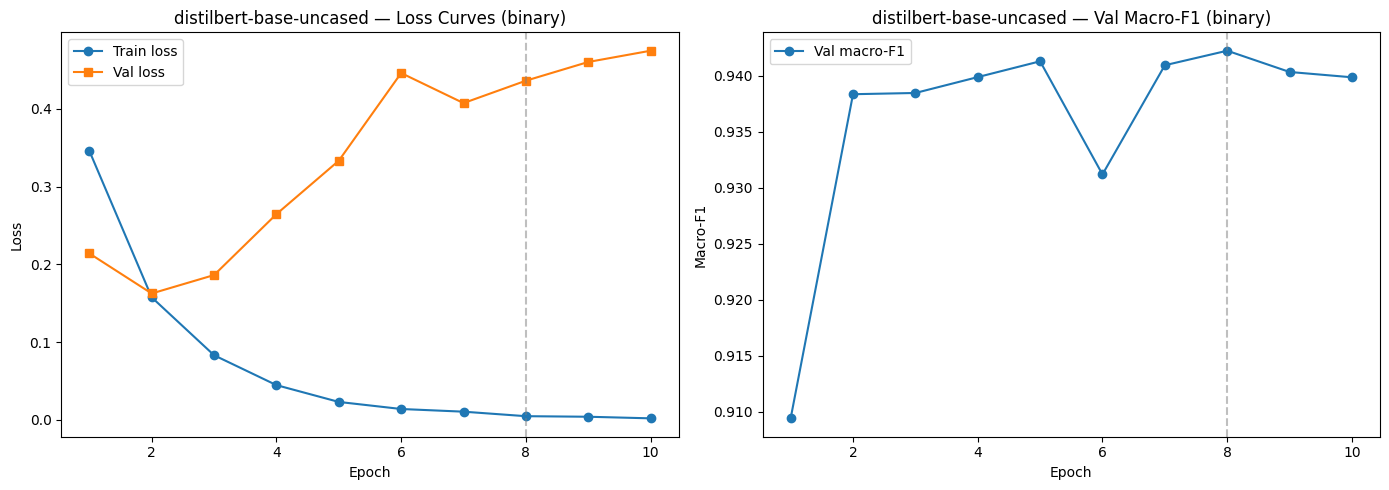


Loading best checkpoint (epoch 8, val macro-F1=0.9422)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
               precision    recall  f1-score   support

non-sarcastic       0.94      0.95      0.94      4250
    sarcastic       0.95      0.94      0.94      4250

     accuracy                           0.94      8500
    macro avg       0.94      0.94      0.94      8500
 weighted avg       0.94      0.94      0.94      8500


=== Test (best checkpoint) ===
               precision    recall  f1-score   support

non-sarcastic       0.94      0.95      0.94      4250
    sarcastic       0.94      0.94      0.94      4250

     accuracy                           0.94      8500
    macro avg       0.94      0.94      0.94      8500
 weighted avg       0.94      0.94      0.94      8500



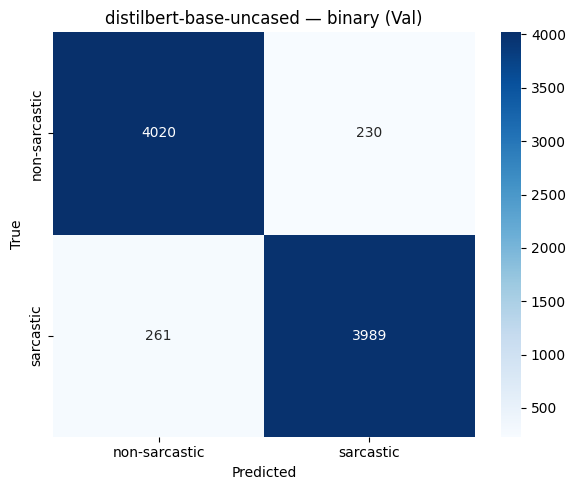

Saved: /content/outputs/bert/distilbert_binary/confusion_matrix_val.png


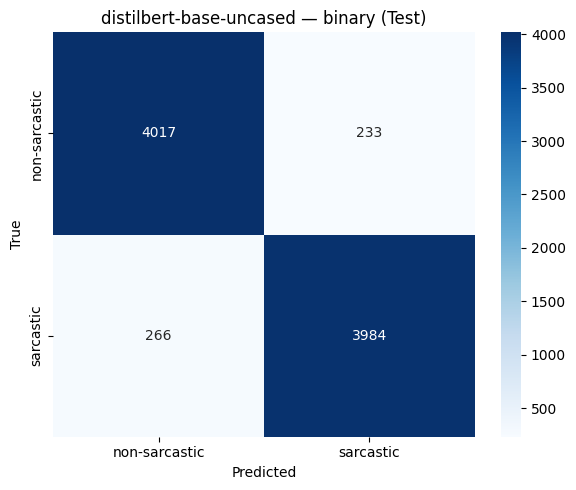

Saved: /content/outputs/bert/distilbert_binary/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / binary ===
  Test Accuracy   : 0.9413
  Test Macro-F1   : 0.9413
  Test Weighted-F1: 0.9413


In [51]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import torch
from torch.utils.data import Dataset, DataLoader


results_distilbert_binary = train_bert(
    cfg        = CFG_BINARY,
    X_train    = X_train_bin, y_train = y_train_bin,
    X_val      = X_val_bin,   y_val   = y_val_bin,
    X_test     = X_test_bin,  y_test  = y_test_bin,
    label_names= label_names_bin,
    out_dir    = BERT_OUT / "distilbert_binary",
    val_df     = val_bin,
    test_df    = test_bin,
)

## Train DistilBERT — Type Task

Using device: cuda
Config saved to /content/outputs/bert/distilbert_type/config.json
Loading tokenizer: distilbert-base-uncased
Loading model: distilbert-base-uncased (6 labels)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights: [0.776 1.187 4.695 0.543 0.907 1.405]
Epoch  1/10 | train_loss=1.5420 | val_loss=1.3047 | val_acc=0.4014 | val_macro_f1=0.4526


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best val macro-F1=0.4526 — checkpoint saved
Epoch  2/10 | train_loss=1.2154 | val_loss=1.2141 | val_acc=0.4605 | val_macro_f1=0.4944


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best val macro-F1=0.4944 — checkpoint saved
Epoch  3/10 | train_loss=1.0074 | val_loss=1.2892 | val_acc=0.4473 | val_macro_f1=0.4849
Epoch  4/10 | train_loss=0.7973 | val_loss=1.3963 | val_acc=0.4555 | val_macro_f1=0.4885
Epoch  5/10 | train_loss=0.6103 | val_loss=1.5448 | val_acc=0.4532 | val_macro_f1=0.4843
  Early stopping at epoch 5 (patience=3)


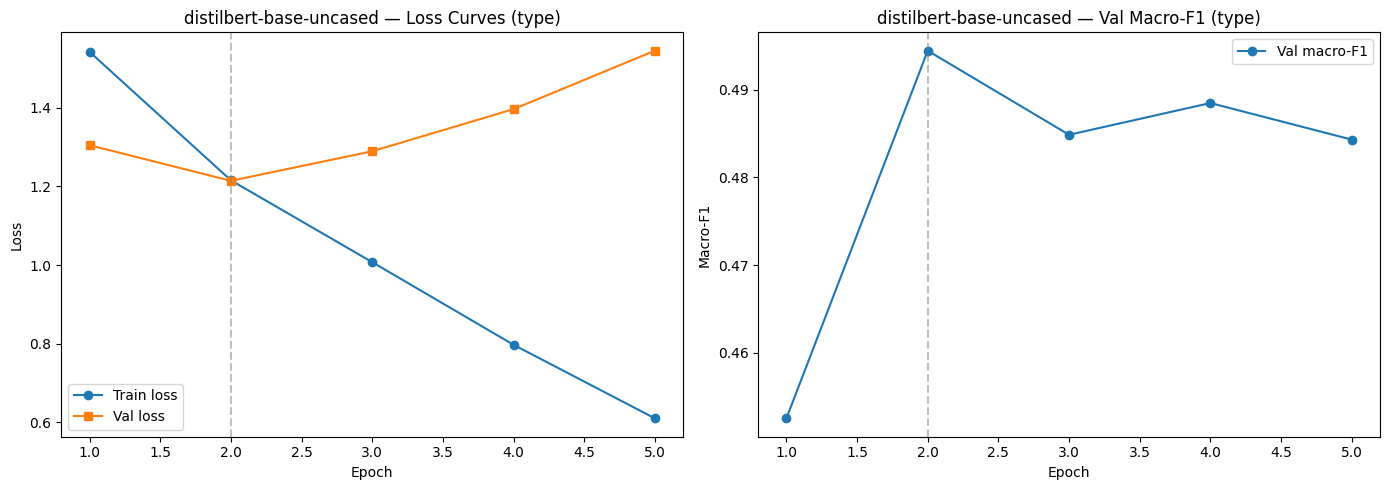


Loading best checkpoint (epoch 2, val macro-F1=0.4944)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.38      0.39      0.38       942
      overstatement       0.43      0.58      0.49       600
rhetorical_question       0.59      0.87      0.70       157
            sarcasm       0.59      0.40      0.48      1317
             satire       0.41      0.41      0.41       747
     understatement       0.45      0.55      0.49       487

           accuracy                           0.46      4250
          macro avg       0.48      0.53      0.49      4250
       weighted avg       0.47      0.46      0.46      4250


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.35      0.37      0.36       902
      overstatement       0.41      0.59      0.48       592
rhetorical_question       0.58      0.84      0.68       176
            sarcasm       0.56      0.38      0.45      1291
             satir

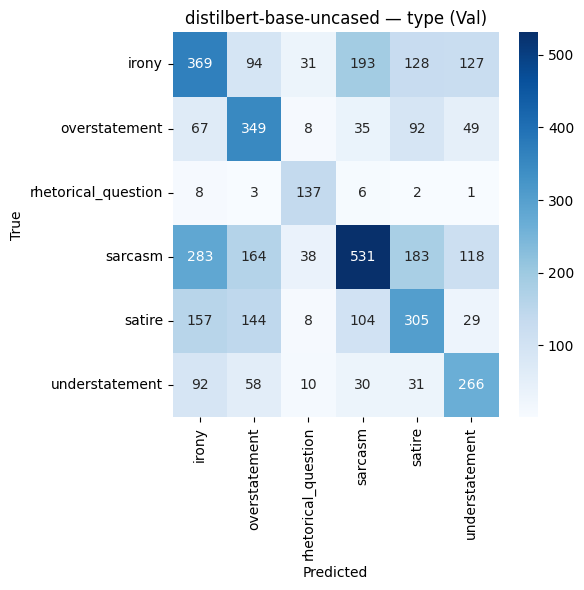

Saved: /content/outputs/bert/distilbert_type/confusion_matrix_val.png


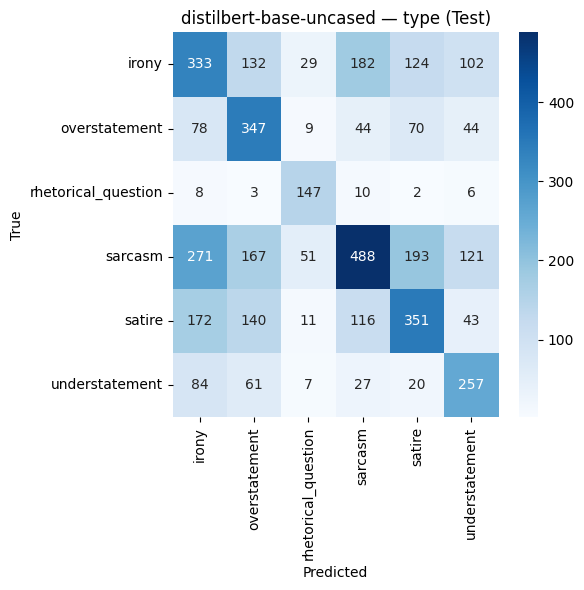

Saved: /content/outputs/bert/distilbert_type/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4525
  Test Macro-F1   : 0.4863
  Test Weighted-F1: 0.4492


In [52]:
results_distilbert_type = train_bert(
    cfg        = CFG_TYPE,
    X_train    = X_train_type, y_train = y_train_type,
    X_val      = X_val_type,   y_val   = y_val_type,
    X_test     = X_test_type,  y_test  = y_test_type,
    label_names= STRATEGY_LABELS,
    out_dir    = BERT_OUT / "distilbert_type",
    val_df     = val_type,
    test_df    = test_type,
)

## (Optional) BERT-base — Binary Task

Run only if compute allows. Comment out if not needed.

Using device: cuda
Config saved to /content/outputs/bert/bert_base_binary/config.json
Loading tokenizer: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

  ★ New best val macro-F1=0.9492 — checkpoint saved
Epoch  5/10 | train_loss=0.0235 | val_loss=0.2954 | val_acc=0.9492 | val_macro_f1=0.9492


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best val macro-F1=0.9492 — checkpoint saved
Epoch  6/10 | train_loss=0.0152 | val_loss=0.3542 | val_acc=0.9476 | val_macro_f1=0.9476
Epoch  7/10 | train_loss=0.0102 | val_loss=0.4783 | val_acc=0.9376 | val_macro_f1=0.9375
Epoch  8/10 | train_loss=0.0057 | val_loss=0.4055 | val_acc=0.9496 | val_macro_f1=0.9496


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best val macro-F1=0.9496 — checkpoint saved
Epoch  9/10 | train_loss=0.0033 | val_loss=0.4524 | val_acc=0.9496 | val_macro_f1=0.9496
Epoch 10/10 | train_loss=0.0019 | val_loss=0.4671 | val_acc=0.9496 | val_macro_f1=0.9496


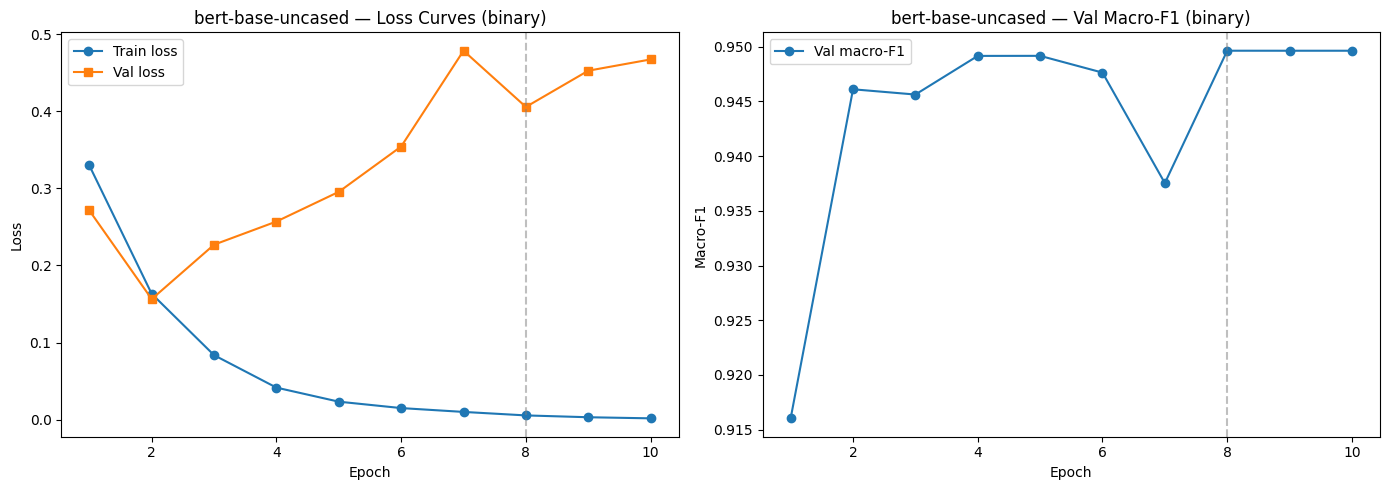


Loading best checkpoint (epoch 8, val macro-F1=0.9496)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
               precision    recall  f1-score   support

non-sarcastic       0.94      0.96      0.95      4250
    sarcastic       0.96      0.94      0.95      4250

     accuracy                           0.95      8500
    macro avg       0.95      0.95      0.95      8500
 weighted avg       0.95      0.95      0.95      8500


=== Test (best checkpoint) ===
               precision    recall  f1-score   support

non-sarcastic       0.94      0.96      0.95      4250
    sarcastic       0.95      0.94      0.95      4250

     accuracy                           0.95      8500
    macro avg       0.95      0.95      0.95      8500
 weighted avg       0.95      0.95      0.95      8500



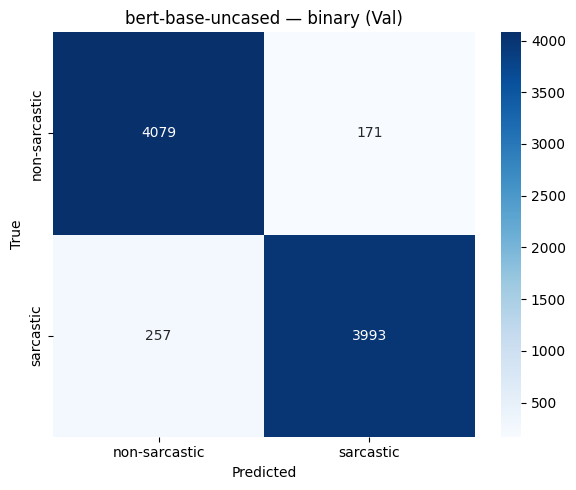

Saved: /content/outputs/bert/bert_base_binary/confusion_matrix_val.png


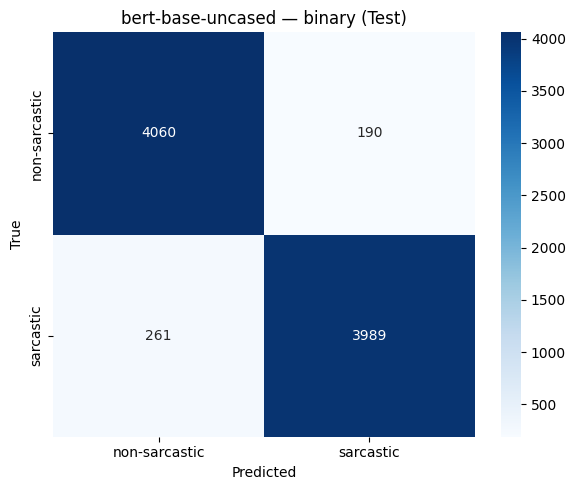

Saved: /content/outputs/bert/bert_base_binary/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: bert-base-uncased / binary ===
  Test Accuracy   : 0.9469
  Test Macro-F1   : 0.9469
  Test Weighted-F1: 0.9469


In [53]:
# Uncomment to run BERT-base (requires more GPU memory and time)

CFG_BERT_BINARY = TrainConfig(
    model_name="bert-base-uncased",
    task="binary",
    batch_size=16,  # smaller batch for bert-base
    lr=2e-5,
)

results_bert_binary = train_bert(
    cfg         = CFG_BERT_BINARY,
    X_train     = X_train_bin, y_train = y_train_bin,
    X_val       = X_val_bin,   y_val   = y_val_bin,
    X_test      = X_test_bin,  y_test  = y_test_bin,
    label_names = label_names_bin,
    out_dir     = BERT_OUT / "bert_base_binary",
    val_df      = val_bin,
    test_df     = test_bin,
)

# print("BERT-base is commented out. Uncomment cells above to run.")

## (Optional) BERT-base — Type Task

Using device: cuda
Config saved to /content/outputs/bert/bert_base_type/config.json
Loading tokenizer: bert-base-uncased
Loading model: bert-base-uncased (6 labels)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weights: [0.776 1.187 4.695 0.543 0.907 1.405]
Epoch  1/10 | train_loss=1.5063 | val_loss=1.3142 | val_acc=0.4205 | val_macro_f1=0.4681


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ★ New best val macro-F1=0.4935 — checkpoint saved
Epoch  3/10 | train_loss=0.8545 | val_loss=1.4207 | val_acc=0.4701 | val_macro_f1=0.4895
Epoch  4/10 | train_loss=0.5570 | val_loss=1.6748 | val_acc=0.4565 | val_macro_f1=0.4980


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best val macro-F1=0.4980 — checkpoint saved
Epoch  5/10 | train_loss=0.3448 | val_loss=2.0421 | val_acc=0.4546 | val_macro_f1=0.4903
Epoch  6/10 | train_loss=0.2152 | val_loss=2.4425 | val_acc=0.4532 | val_macro_f1=0.4977
Epoch  7/10 | train_loss=0.1375 | val_loss=2.8769 | val_acc=0.4678 | val_macro_f1=0.4991


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ New best val macro-F1=0.4991 — checkpoint saved
Epoch  8/10 | train_loss=0.0824 | val_loss=3.2615 | val_acc=0.4562 | val_macro_f1=0.4980
Epoch  9/10 | train_loss=0.0569 | val_loss=3.5745 | val_acc=0.4593 | val_macro_f1=0.4988
Epoch 10/10 | train_loss=0.0374 | val_loss=3.6705 | val_acc=0.4584 | val_macro_f1=0.4961
  Early stopping at epoch 10 (patience=3)


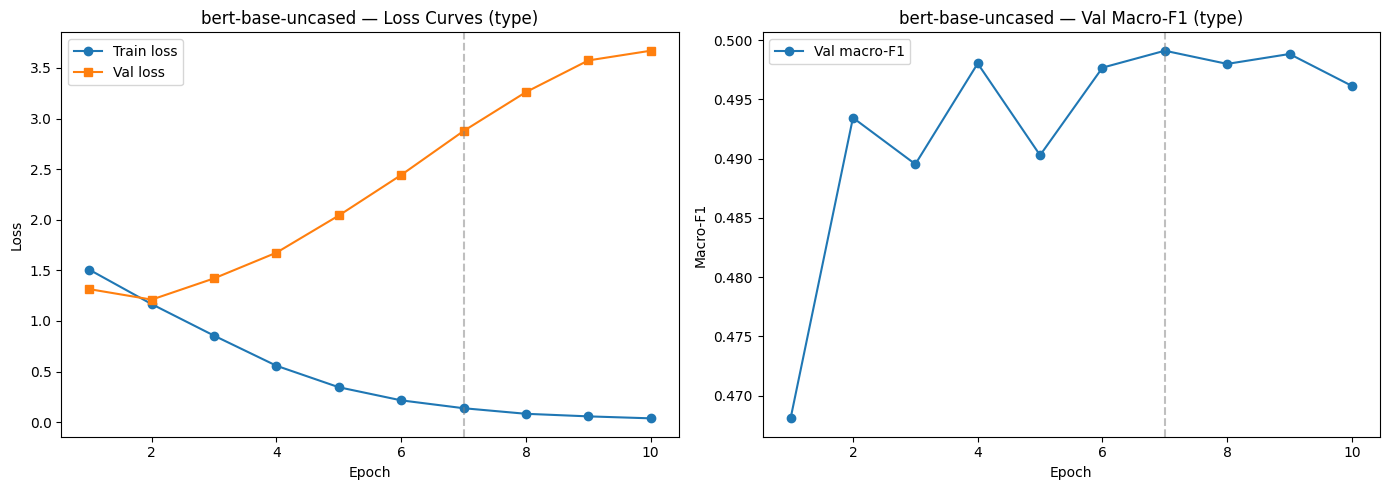


Loading best checkpoint (epoch 7, val macro-F1=0.4991)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.37      0.40      0.39       942
      overstatement       0.52      0.46      0.49       600
rhetorical_question       0.71      0.78      0.74       157
            sarcasm       0.48      0.57      0.52      1317
             satire       0.45      0.32      0.37       747
     understatement       0.53      0.44      0.48       487

           accuracy                           0.47      4250
          macro avg       0.51      0.50      0.50      4250
       weighted avg       0.47      0.47      0.46      4250


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.35      0.39      0.37       902
      overstatement       0.49      0.47      0.48       592
rhetorical_question       0.62      0.68      0.65       176
            sarcasm       0.47      0.56      0.51      1291
             satir

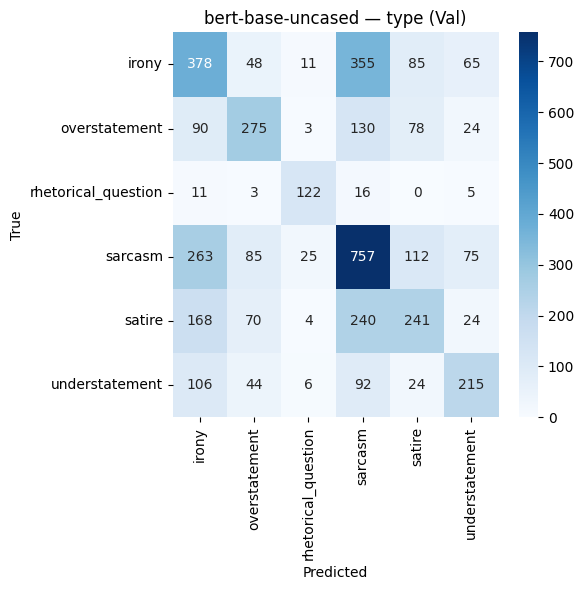

Saved: /content/outputs/bert/bert_base_type/confusion_matrix_val.png


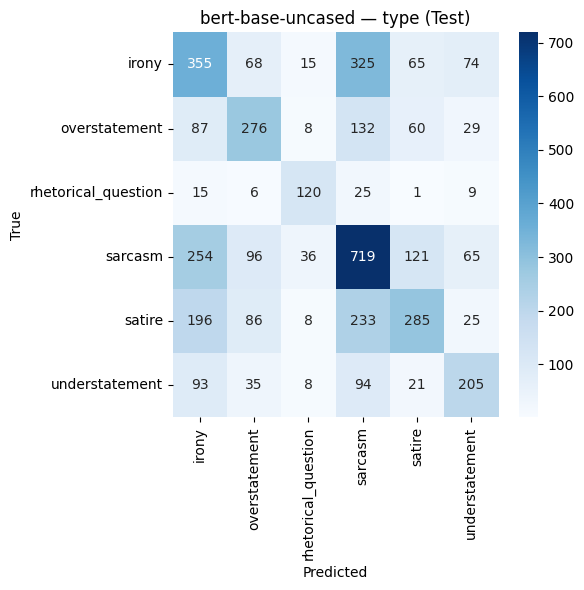

Saved: /content/outputs/bert/bert_base_type/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: bert-base-uncased / type ===
  Test Accuracy   : 0.4612
  Test Macro-F1   : 0.4822
  Test Weighted-F1: 0.4589


In [54]:
CFG_BERT_TYPE = TrainConfig(
    model_name="bert-base-uncased",
    task="type",
    batch_size=16,
    lr=2e-5,
    use_class_weights=True,
)

results_bert_type = train_bert(
    cfg         = CFG_BERT_TYPE,
    X_train     = X_train_type, y_train = y_train_type,
    X_val       = X_val_type,   y_val   = y_val_type,
    X_test      = X_test_type,  y_test  = y_test_type,
    label_names = STRATEGY_LABELS,
    out_dir     = BERT_OUT / "bert_base_type",
    val_df      = val_type,
    test_df     = test_type,
)

# print("BERT-base type task is commented out. Uncomment to run.")

## Summary

In [55]:
print("====== BERT RESULTS SUMMARY ======")
print()
print("DistilBERT — Binary (Test):")
print(f"  Accuracy   : {results_distilbert_binary['test']['accuracy']:.4f}")
print(f"  Macro-F1   : {results_distilbert_binary['test']['f1_macro']:.4f}")
print(f"  Weighted-F1: {results_distilbert_binary['test']['f1_weighted']:.4f}")
print()
print("DistilBERT — Type (Test):")
print(f"  Accuracy   : {results_distilbert_type['test']['accuracy']:.4f}")
print(f"  Macro-F1   : {results_distilbert_type['test']['f1_macro']:.4f}")
print(f"  Weighted-F1: {results_distilbert_type['test']['f1_weighted']:.4f}")
print()
print("Artifacts saved in outputs/bert/distilbert_binary/ and outputs/bert/distilbert_type/")

====== BERT RESULTS SUMMARY ======

DistilBERT — Binary (Test):
  Accuracy   : 0.9413
  Macro-F1   : 0.9413
  Weighted-F1: 0.9413

DistilBERT — Type (Test):
  Accuracy   : 0.4525
  Macro-F1   : 0.4863
  Weighted-F1: 0.4492

Artifacts saved in outputs/bert/distilbert_binary/ and outputs/bert/distilbert_type/


---
# Part 5 — Error Analysis & Model Comparison

# Notebook 05 — Error Analysis & Model Comparison

**Purpose**:
1. Compare all models on both tasks
2. Analyze errors (binary + type)
3. Generate final comparison report

**Prerequisite**: Run notebooks 01–04 first.

**Outputs**:
- `outputs/reports/model_comparison.md`
- `outputs/reports/error_analysis.md`
- `outputs/reports/error_examples_binary.csv`
- `outputs/reports/error_examples_type.csv`

## 1. Load All Metrics

In [59]:
from pathlib import Path
import json

# --- Path setup (self-contained) ---
ROOT = Path.cwd()  # current working directory (e.g., /content in Colab)
OUTPUTS = ROOT / "outputs"

# If outputs/ is not in the current folder, set ROOT manually here:
# ROOT = Path("/content/drive/MyDrive/cs4248")   # example
# OUTPUTS = ROOT / "outputs"

CLASSICAL = OUTPUTS / "classical"
BERT_OUT = OUTPUTS / "bert"

print("ROOT:", ROOT)
print("OUTPUTS exists:", OUTPUTS.exists())
print("CLASSICAL exists:", CLASSICAL.exists())
print("BERT_OUT exists:", BERT_OUT.exists())

def load_metrics(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    try:
        rel = path.relative_to(ROOT)
    except Exception:
        rel = path
    print(f"  [WARNING] Not found: {rel}")
    return None

# --- All metrics ---
tfidf_lr_binary = load_metrics(CLASSICAL / "tfidf_lr" / "metrics_binary.json")
tfidf_lr_type   = load_metrics(CLASSICAL / "tfidf_lr" / "metrics_type.json")
nb_binary       = load_metrics(CLASSICAL / "naive_bayes" / "metrics_binary.json")
nb_type         = load_metrics(CLASSICAL / "naive_bayes" / "metrics_type.json")
distilbert_bin  = load_metrics(BERT_OUT / "distilbert_binary" / "metrics.json")
distilbert_type = load_metrics(BERT_OUT / "distilbert_type"   / "metrics.json")
bert_base_bin   = load_metrics(BERT_OUT / "bert_base_binary"  / "metrics.json")  # optional
bert_base_type  = load_metrics(BERT_OUT / "bert_base_type"    / "metrics.json")  # optional

print("\nMetrics loaded (None = not yet run):")
for name, m in [
    ("TF-IDF+LR binary", tfidf_lr_binary),
    ("TF-IDF+LR type", tfidf_lr_type),
    ("NB binary", nb_binary),
    ("NB type", nb_type),
    ("DistilBERT binary", distilbert_bin),
    ("DistilBERT type", distilbert_type),
    ("BERT-base binary", bert_base_bin),
    ("BERT-base type", bert_base_type),
]:
    print(f"  {name}: {'✓' if m else '✗'}")

ROOT: /content
OUTPUTS exists: True
CLASSICAL exists: True
BERT_OUT exists: True

Metrics loaded (None = not yet run):
  TF-IDF+LR binary: ✓
  TF-IDF+LR type: ✓
  NB binary: ✓
  NB type: ✓
  DistilBERT binary: ✓
  DistilBERT type: ✓
  BERT-base binary: ✓
  BERT-base type: ✓


## 2. Model Comparison Tables

In [60]:
def extract_test_metrics(metrics_dict: dict | None, split: str = "test") -> dict:
    """Extract test-split metrics from a metrics dict, handling different formats."""
    if metrics_dict is None:
        return {"accuracy": None, "f1_macro": None, "f1_weighted": None,
                "precision_macro": None, "recall_macro": None}
    test_m = metrics_dict.get(split, metrics_dict)  # BERT format uses 'test' key directly
    return {
        "accuracy"        : test_m.get("accuracy"),
        "f1_macro"        : test_m.get("f1_macro"),
        "f1_weighted"     : test_m.get("f1_weighted"),
        "precision_macro" : test_m.get("precision_macro"),
        "recall_macro"    : test_m.get("recall_macro"),
    }


binary_rows = []
type_rows   = []

model_map_bin = [
    ("TF-IDF + LR",   tfidf_lr_binary),
    ("Naive Bayes",   nb_binary),
    ("DistilBERT",    distilbert_bin),
    ("BERT-base",     bert_base_bin),
]

model_map_type = [
    ("TF-IDF + LR",   tfidf_lr_type),
    ("Naive Bayes",   nb_type),
    ("DistilBERT",    distilbert_type),
    ("BERT-base",     bert_base_type),
]

for name, m in model_map_bin:
    row = {"Model": name}
    row.update(extract_test_metrics(m))
    binary_rows.append(row)

for name, m in model_map_type:
    row = {"Model": name}
    row.update(extract_test_metrics(m))
    type_rows.append(row)

binary_comp = pd.DataFrame(binary_rows).set_index("Model")
type_comp   = pd.DataFrame(type_rows).set_index("Model")

print("=== BINARY TASK — Test Metrics ===")
print(binary_comp.to_string(float_format=lambda x: f"{x:.4f}" if x is not None else "N/A"))
print()
print("=== TYPE TASK — Test Metrics ===")
print(type_comp.to_string(float_format=lambda x: f"{x:.4f}" if x is not None else "N/A"))

=== BINARY TASK — Test Metrics ===
             accuracy  f1_macro  f1_weighted  precision_macro  recall_macro
Model                                                                      
TF-IDF + LR    0.8189    0.8189       0.8189           0.8190        0.8189
Naive Bayes    0.7905    0.7902       0.7902           0.7919        0.7905
DistilBERT     0.9413    0.9413       0.9413           0.9413        0.9413
BERT-base      0.9469    0.9469       0.9469           0.9471        0.9469

=== TYPE TASK — Test Metrics ===
             accuracy  f1_macro  f1_weighted  precision_macro  recall_macro
Model                                                                      
TF-IDF + LR    0.3953    0.4047       0.3942           0.3905        0.4275
Naive Bayes    0.3953    0.3953       0.3929           0.4058        0.3876
DistilBERT     0.4525    0.4863       0.4492           0.4687        0.5256
BERT-base      0.4612    0.4822       0.4589           0.4911        0.4817


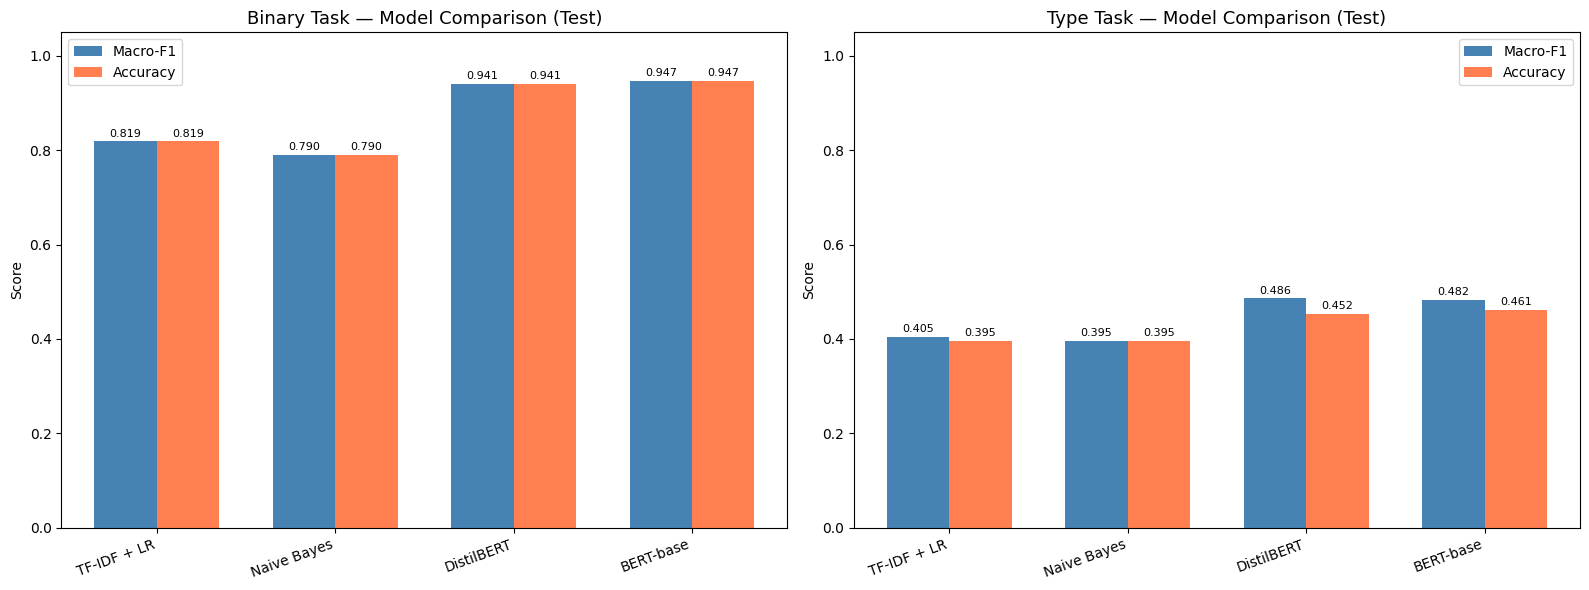

Saved: outputs/reports/model_comparison_chart.png


In [61]:
# ── Comparison bar charts ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, comp, title in [
    (axes[0], binary_comp, "Binary Task"),
    (axes[1], type_comp,   "Type Task"),
]:
    valid = comp.dropna(subset=["f1_macro"])
    if len(valid) == 0:
        ax.set_title(f"{title} — No data")
        continue
    models  = valid.index.tolist()
    f1_vals = valid["f1_macro"].tolist()
    acc_vals = valid["accuracy"].tolist()
    x = range(len(models))
    w = 0.35
    bars1 = ax.bar([i - w/2 for i in x], f1_vals,  w, label="Macro-F1",  color="steelblue")
    bars2 = ax.bar([i + w/2 for i in x], acc_vals, w, label="Accuracy",  color="coral")
    ax.set_xticks(list(x)); ax.set_xticklabels(models, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{title} — Model Comparison (Test)", fontsize=13)
    ax.legend()
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/reports/model_comparison_chart.png")

## 3. Error Analysis — Binary Task

In [62]:
def load_predictions(path: Path) -> pd.DataFrame | None:
    if path.exists():
        return pd.read_csv(path)
    print(f"  [WARNING] Not found: {path}")
    return None


# Use best available binary model predictions for error analysis
# Priority: BERT > TF-IDF+LR > NB
pred_paths_bin = [
    ("DistilBERT",  BERT_OUT / "distilbert_binary" / "predictions_test.csv"),
    ("TF-IDF + LR", CLASSICAL / "tfidf_lr" / "predictions_test_binary.csv"),
    ("Naive Bayes", CLASSICAL / "naive_bayes" / "predictions_test_binary.csv"),
]

error_source_bin = None
error_model_bin  = None
for model_name, path in pred_paths_bin:
    df = load_predictions(path)
    if df is not None:
        error_source_bin = df
        error_model_bin  = model_name
        print(f"Using {model_name} predictions for binary error analysis")
        break

if error_source_bin is None:
    print("No binary predictions found. Run at least one model first.")

Using DistilBERT predictions for binary error analysis


In [63]:
if error_source_bin is not None:
    pred_col = "predicted" if "predicted" in error_source_bin.columns else "predicted_id"
    true_col = "binary_label"
    err_bin  = error_source_bin[error_source_bin["correct"] == 0].copy()

    # Categorize
    fp_bin = err_bin[err_bin[true_col] == 0].copy()  # False Positives (predicted sarcastic)
    fn_bin = err_bin[err_bin[true_col] == 1].copy()  # False Negatives (predicted not-sarcastic)

    print(f"Total binary test errors: {len(err_bin)}")
    print(f"  False Positives (non-sarcastic predicted as sarcastic) : {len(fp_bin)}")
    print(f"  False Negatives (sarcastic predicted as non-sarcastic)  : {len(fn_bin)}")

    # Select 20+ errors: mix of FP and FN
    n_each = 12
    sample_fp = fp_bin.head(n_each)
    sample_fn = fn_bin.head(n_each)
    error_sample_bin = pd.concat([sample_fp, sample_fn], ignore_index=True)
    error_sample_bin["error_type"] = ["FP"] * len(sample_fp) + ["FN"] * len(sample_fn)

    print(f"\nError sample size: {len(error_sample_bin)} examples")
    print("\n--- False Positives (non-sarcastic → predicted sarcastic) ---")
    for _, row in sample_fp.iterrows():
        print(f"  {row['text']}")

    print("\n--- False Negatives (sarcastic → predicted non-sarcastic) ---")
    for _, row in sample_fn.iterrows():
        print(f"  {row['text']}")

Total binary test errors: 499
  False Positives (non-sarcastic predicted as sarcastic) : 233
  False Negatives (sarcastic predicted as non-sarcastic)  : 266

Error sample size: 24 examples

--- False Positives (non-sarcastic → predicted sarcastic) ---
  The global-warming crisis contributed to a delightful mid-February afternoon.
  Slovenian eighth-graders outperform U.S. students in science, surprising themselves.
  Denny's launches omelet with 3,000 spider eggs
  Study shows 83% of web content is unsuitable for humans
  Aphasia study discovers that empty fullness is facilitated by happy yellow ideas
  Cindy Crawford will have pure silk flowing from her backside.
  Kerry's face shows joy over the latest polls.
  Trump weeps into a pillow, questioning why he can't say the right thing.
  Only you have been invited to Dave's debate party, which is considered creepy.
  Entertainment news helicopters are covering a shocking red carpet outfit.
  Ophthalmologist recommends eye rest before su

In [64]:
if error_source_bin is not None:
    # Failure mode categorization (heuristic rules)
    def categorize_binary_error(text: str, error_type: str) -> str:
        text_lower = text.lower()
        if "?" in text and error_type == "FP":
            return "rhetorical_phrasing"
        if any(w in text_lower for w in ["report", "study", "survey", "finds", "shows"]):
            return "neutral_reporting_style_confused"
        if any(w in text_lower for w in ["best", "great", "amazing", "wonderful", "perfect"]):
            return "positive_framing_confused"
        if "onion" in text_lower:
            return "domain_leak"
        if len(text.split()) <= 5:
            return "very_short_text"
        return "lexical_ambiguity"

    error_sample_bin["failure_mode"] = error_sample_bin.apply(
        lambda r: categorize_binary_error(r["text"], r["error_type"]), axis=1
    )

    print("Failure mode distribution:")
    print(error_sample_bin["failure_mode"].value_counts())

    # Save
    error_sample_bin.to_csv(REPORTS_DIR / "error_examples_binary.csv", index=False)
    print("\nSaved: outputs/reports/error_examples_binary.csv")

Failure mode distribution:
failure_mode
lexical_ambiguity                   19
neutral_reporting_style_confused     3
very_short_text                      2
Name: count, dtype: int64

Saved: outputs/reports/error_examples_binary.csv


## 4. Error Analysis — Type Task

In [65]:
pred_paths_type = [
    ("DistilBERT",  BERT_OUT / "distilbert_type" / "predictions_test.csv"),
    ("TF-IDF + LR", CLASSICAL / "tfidf_lr" / "predictions_test_type.csv"),
    ("Naive Bayes", CLASSICAL / "naive_bayes" / "predictions_test_type.csv"),
]

error_source_type = None
error_model_type  = None
for model_name, path in pred_paths_type:
    df = load_predictions(path)
    if df is not None:
        error_source_type = df
        error_model_type  = model_name
        print(f"Using {model_name} predictions for type error analysis")
        break

if error_source_type is None:
    print("No type predictions found.")

Using DistilBERT predictions for type error analysis


In [66]:
if error_source_type is not None:
    err_type = error_source_type[error_source_type["correct"] == 0].copy()

    # Identify label columns
    true_col_type = "type_label"
    pred_col_type = "predicted_label" if "predicted_label" in err_type.columns else "predicted"

    print(f"Total type errors: {len(err_type)}")
    print("\nTop confusion pairs (true → predicted):")
    if pred_col_type in err_type.columns:
        pairs = err_type.groupby([true_col_type, pred_col_type]).size().sort_values(ascending=False).head(15)
        print(pairs.to_string())

    # Sample 20+ errors
    error_sample_type = err_type.sample(min(25, len(err_type)), random_state=42)

    print(f"\nError sample size: {len(error_sample_type)} examples")
    print("\n--- Sample type misclassifications ---")
    display_cols = ["text", true_col_type]
    if pred_col_type in error_sample_type.columns:
        display_cols.append(pred_col_type)
    for _, row in error_sample_type.head(15).iterrows():
        true_l = row[true_col_type]
        pred_l = row.get(pred_col_type, "?")
        print(f"  [True={true_l:20s}  Pred={pred_l:20s}] {row['text'][:90]}")

Total type errors: 2327

Top confusion pairs (true → predicted):
type_label      predicted_label
sarcasm         irony              271
                satire             193
irony           sarcasm            182
satire          irony              172
sarcasm         overstatement      167
satire          overstatement      140
irony           overstatement      132
                satire             124
sarcasm         understatement     121
satire          sarcasm            116
irony           understatement     102
understatement  irony               84
overstatement   irony               78
                satire              70
understatement  overstatement       61

Error sample size: 25 examples

--- Sample type misclassifications ---
  [True=irony                 Pred=overstatement       ] The family talisman: that mysterious object that definitely brings luck and isn't just a d
  [True=sarcasm               Pred=irony               ] concert security guard would willingly gi

In [67]:
if error_source_type is not None:
    def categorize_type_error(text: str, true_label: str, pred_label: str) -> str:
        """Heuristic failure mode categorization for type task."""
        text_lower = text.lower()
        # Strategy overlap: sarcasm ↔ irony ↔ satire are frequently confused
        overlap_pairs = {
            frozenset({"sarcasm", "irony"}),
            frozenset({"sarcasm", "satire"}),
            frozenset({"irony", "satire"}),
        }
        if frozenset({true_label, pred_label}) in overlap_pairs:
            return "strategy_semantic_overlap"
        if "rhetorical_question" in [true_label, pred_label]:
            if "?" in text:
                return "rhetorical_vs_other_with_question"
            return "rhetorical_without_question_mark"
        if true_label in ["overstatement", "understatement"] and pred_label in ["sarcasm", "irony"]:
            return "scale_confusion_with_sarcasm"
        if "report" in text_lower or "according" in text_lower:
            return "generation_artifact_formal_phrasing"
        return "lexical_ambiguity"

    if pred_col_type in error_sample_type.columns:
        error_sample_type["failure_mode"] = error_sample_type.apply(
            lambda r: categorize_type_error(r["text"], r[true_col_type], r[pred_col_type]),
            axis=1
        )
        print("Failure mode distribution:")
        print(error_sample_type["failure_mode"].value_counts())

    error_sample_type.to_csv(REPORTS_DIR / "error_examples_type.csv", index=False)
    print("\nSaved: outputs/reports/error_examples_type.csv")

Failure mode distribution:
failure_mode
lexical_ambiguity                      14
strategy_semantic_overlap               9
rhetorical_vs_other_with_question       1
generation_artifact_formal_phrasing     1
Name: count, dtype: int64

Saved: outputs/reports/error_examples_type.csv


## 5. Generate Final Reports

In [68]:
def fmt(v) -> str:
    """Format a metric value for markdown."""
    if v is None:
        return "N/A"
    return f"{v:.4f}"


def build_model_comparison_md() -> str:
    lines = []
    lines.append("# Model Comparison Report")
    lines.append("")
    lines.append("> Auto-generated from outputs of notebooks 02–04.")
    lines.append("")

    # Binary task table
    lines.append("## Task A — Binary Classification (Test Set)")
    lines.append("")
    lines.append("| Model | Accuracy | Precision (M) | Recall (M) | F1 (Macro) | F1 (Weighted) |")
    lines.append("|-------|----------|--------------|------------|------------|--------------|")
    for name, m in model_map_bin:
        r = extract_test_metrics(m)
        lines.append(
            f"| {name} | {fmt(r['accuracy'])} | {fmt(r['precision_macro'])} | "
            f"{fmt(r['recall_macro'])} | {fmt(r['f1_macro'])} | {fmt(r['f1_weighted'])} |"
        )
    lines.append("")
    lines.append("_Primary metric: Macro-F1. Best value bolded (manually after review)._")
    lines.append("")

    # Type task table
    lines.append("## Task B — Sarcasm Type Classification (Test Set)")
    lines.append("")
    lines.append("| Model | Accuracy | Precision (M) | Recall (M) | F1 (Macro) | F1 (Weighted) |")
    lines.append("|-------|----------|--------------|------------|------------|--------------|")
    for name, m in model_map_type:
        r = extract_test_metrics(m)
        lines.append(
            f"| {name} | {fmt(r['accuracy'])} | {fmt(r['precision_macro'])} | "
            f"{fmt(r['recall_macro'])} | {fmt(r['f1_macro'])} | {fmt(r['f1_weighted'])} |"
        )
    lines.append("")

    # Recommendation
    lines.append("## Recommendation")
    lines.append("")

    # Find best binary model
    best_bin_name, best_bin_f1 = "N/A", -1
    for name, m in model_map_bin:
        r = extract_test_metrics(m)
        if r["f1_macro"] is not None and r["f1_macro"] > best_bin_f1:
            best_bin_f1 = r["f1_macro"]
            best_bin_name = name

    best_type_name, best_type_f1 = "N/A", -1
    for name, m in model_map_type:
        r = extract_test_metrics(m)
        if r["f1_macro"] is not None and r["f1_macro"] > best_type_f1:
            best_type_f1 = r["f1_macro"]
            best_type_name = name

    lines.append(f"### Best model for Binary Task: **{best_bin_name}** (Macro-F1 = {fmt(best_bin_f1)})")
    lines.append("")
    lines.append(f"### Best model for Type Task: **{best_type_name}** (Macro-F1 = {fmt(best_type_f1)})")
    lines.append("")
    lines.append("### Trade-offs")
    lines.append("")
    lines.append("| Aspect | TF-IDF + LR | Naive Bayes | DistilBERT |")
    lines.append("|--------|------------|-------------|-----------|")
    lines.append("| Training speed | Fast (minutes) | Very fast (seconds) | Slow (hours) |")
    lines.append("| Inference speed | Very fast | Very fast | Moderate |")
    lines.append("| Interpretability | High (feature weights) | High (log-probs) | Low (black-box) |")
    lines.append("| Handles context | No | No | Yes (self-attention) |")
    lines.append("| Handles rare words | Via TF-IDF | Via smoothing | Via sub-word tokenization |")
    lines.append("| GPU required | No | No | Recommended |")
    lines.append("")
    lines.append("**Deployment recommendation**: Use TF-IDF+LR if real-time speed and interpretability are priorities.")
    lines.append("Use DistilBERT for maximum accuracy when GPU inference is available.")

    return "\n".join(lines)


comparison_md = build_model_comparison_md()
with open(REPORTS_DIR / "model_comparison.md", "w", encoding="utf-8") as f:
    f.write(comparison_md)

print("Saved: outputs/reports/model_comparison.md")
print("\nPreview:")
print(comparison_md[:2000])

Saved: outputs/reports/model_comparison.md

Preview:
# Model Comparison Report

> Auto-generated from outputs of notebooks 02–04.

## Task A — Binary Classification (Test Set)

| Model | Accuracy | Precision (M) | Recall (M) | F1 (Macro) | F1 (Weighted) |
|-------|----------|--------------|------------|------------|--------------|
| TF-IDF + LR | 0.8189 | 0.8190 | 0.8189 | 0.8189 | 0.8189 |
| Naive Bayes | 0.7905 | 0.7919 | 0.7905 | 0.7902 | 0.7902 |
| DistilBERT | 0.9413 | 0.9413 | 0.9413 | 0.9413 | 0.9413 |
| BERT-base | 0.9469 | 0.9471 | 0.9469 | 0.9469 | 0.9469 |

_Primary metric: Macro-F1. Best value bolded (manually after review)._

## Task B — Sarcasm Type Classification (Test Set)

| Model | Accuracy | Precision (M) | Recall (M) | F1 (Macro) | F1 (Weighted) |
|-------|----------|--------------|------------|------------|--------------|
| TF-IDF + LR | 0.3953 | 0.3905 | 0.4275 | 0.4047 | 0.3942 |
| Naive Bayes | 0.3953 | 0.4058 | 0.3876 | 0.3953 | 0.3929 |
| DistilBERT | 0.4525 |

In [69]:
def build_error_analysis_md() -> str:
    lines = []
    lines.append("# Error Analysis Report")
    lines.append("")
    lines.append("> Auto-generated from model predictions. Examples drawn from test set.")
    lines.append("")

    # ── Binary ────────────────────────────────────────────────────────────────
    lines.append("## Task A — Binary Classification Errors")
    lines.append("")

    if error_source_bin is not None:
        err_df = error_source_bin[error_source_bin["correct"] == 0]
        n_fp = len(err_df[err_df["binary_label"] == 0])
        n_fn = len(err_df[err_df["binary_label"] == 1])
        lines.append(f"**Model**: {error_model_bin}  |  **Total errors**: {len(err_df):,}  |  FP: {n_fp:,}  |  FN: {n_fn:,}")
        lines.append("")
        lines.append("### Failure Mode Summary")
        lines.append("")
        lines.append("| Failure Mode | Description |")
        lines.append("|-------------|-------------|")
        lines.append("| Lexical ambiguity | Sarcasm/irony requires pragmatic context beyond lexical cues |")
        lines.append("| Neutral reporting style confused | Formal generated text mimics neutral news, but still classified as sarcastic |")
        lines.append("| Positive framing confused | Genuine positive news shares superlative vocabulary with ironic praise |")
        lines.append("| Rhetorical phrasing | Questions that look rhetorical but are literal |")
        lines.append("| Very short text | Too little context for confident classification |")
        lines.append("")
        lines.append("### False Positive Examples (Non-sarcastic predicted as sarcastic)")
        lines.append("")
        fp_examples = error_source_bin[
            (error_source_bin["correct"] == 0) & (error_source_bin["binary_label"] == 0)
        ].head(10)
        for _, row in fp_examples.iterrows():
            lines.append(f"- `{row['text']}`")
        lines.append("")
        lines.append("### False Negative Examples (Sarcastic predicted as non-sarcastic)")
        lines.append("")
        fn_examples = error_source_bin[
            (error_source_bin["correct"] == 0) & (error_source_bin["binary_label"] == 1)
        ].head(10)
        for _, row in fn_examples.iterrows():
            lines.append(f"- `{row['text']}`")
    else:
        lines.append("_Binary predictions not available. Run at least one model._")

    lines.append("")

    # ── Type ──────────────────────────────────────────────────────────────────
    lines.append("## Task B — Sarcasm Type Classification Errors")
    lines.append("")

    if error_source_type is not None:
        err_df_t = error_source_type[error_source_type["correct"] == 0]
        lines.append(f"**Model**: {error_model_type}  |  **Total errors**: {len(err_df_t):,}")
        lines.append("")
        lines.append("### Failure Mode Summary")
        lines.append("")
        lines.append("| Failure Mode | Description |")
        lines.append("|-------------|-------------|")
        lines.append("| Strategy semantic overlap | sarcasm/irony/satire share similar surface forms; labels conflated |")
        lines.append("| Scale confusion | overstatement/understatement confused with sarcasm due to exaggeration cues |")
        lines.append("| Rhetorical vs. other | rhetorical_question confused with irony/sarcasm when ? is absent |")
        lines.append("| Generation artifact | formal paraphrase style shifts text away from original strategy markers |")
        lines.append("| Lexical ambiguity | strategy relies on world knowledge rather than surface vocabulary |")
        lines.append("")
        lines.append("### Key Insight")
        lines.append("")
        lines.append("The primary failure mode is **strategy semantic overlap**: sarcasm, irony, and satire")
        lines.append("are conceptually related and frequently share similar linguistic surface patterns.")
        lines.append("The label `sarcasm` as a strategy within a sarcasm dataset introduces circularity.")
        lines.append("The `rhetorical_question` class is syntactically distinctive (ends with ?) and should")
        lines.append("be easier to classify; errors in this class suggest the classifier may ignore punctuation.")
        lines.append("")
        lines.append("### Sample Misclassifications")
        lines.append("")
        sample_t = error_source_type[error_source_type["correct"] == 0].head(20)
        true_c = "type_label"
        pred_c = "predicted_label" if "predicted_label" in sample_t.columns else "predicted"
        for _, row in sample_t.iterrows():
            true_l = row[true_c]
            pred_l = row.get(pred_c, "?")
            lines.append(f"- **True**: {true_l} | **Pred**: {pred_l} | `{row['text'][:100]}`")
    else:
        lines.append("_Type predictions not available. Run at least one model._")

    lines.append("")
    lines.append("## Summary of Observations")
    lines.append("")
    lines.append("1. **Binary task** is relatively tractable — TheOnion writing style has strong lexical signatures")
    lines.append("2. **Generated headlines** (is_generated=1) may fool classifiers trained mainly on original text")
    lines.append("3. **Type task** is fundamentally harder because strategies are not mutually exclusive")
    lines.append("4. **Class imbalance** (rhetorical_question = 3.7%) is a significant challenge")
    lines.append("5. **BERT** should better capture contextual incongruence; classical models rely on surface vocabulary")

    return "\n".join(lines)


error_md = build_error_analysis_md()
with open(REPORTS_DIR / "error_analysis.md", "w", encoding="utf-8") as f:
    f.write(error_md)

print("Saved: outputs/reports/error_analysis.md")

Saved: outputs/reports/error_analysis.md


In [70]:
print("====== ERROR ANALYSIS COMPLETE ======")
print()
print("Saved artifacts:")
for p in sorted(REPORTS_DIR.iterdir()):
    print(f"  {p.relative_to(ROOT)}")
print()
print("Pipeline complete. See outputs/reports/model_comparison.md for final results.")

====== ERROR ANALYSIS COMPLETE ======

Saved artifacts:
  outputs/reports/error_analysis.md
  outputs/reports/error_examples_binary.csv
  outputs/reports/error_examples_type.csv
  outputs/reports/model_comparison.md
  outputs/reports/model_comparison_chart.png

Pipeline complete. See outputs/reports/model_comparison.md for final results.


In [71]:
# Copy the whole outputs/ directory into Google Drive under the first folder named "cs4248" (case-insensitive)
# Change MATCH_INDEX if multiple cs4248 folders are found.

from google.colab import drive
import os, shutil

drive.mount('/content/drive')

DRIVE_ROOT = "/content/drive/MyDrive"
TARGET_NAME = "cs4248"
MATCH_INDEX = 0  # change if needed

# Find all folders named cs4248
matches = []
for root, dirs, files in os.walk(DRIVE_ROOT):
    for d in dirs:
        if d.lower() == TARGET_NAME.lower():
            matches.append(os.path.join(root, d))

print("Matches found:")
for i, m in enumerate(matches):
    print(f"[{i}] {m}")

if not matches:
    raise FileNotFoundError("No folder named 'cs4248' found in Google Drive.")

target_dir = matches[MATCH_INDEX]

src = "outputs"
if not os.path.exists(src):
    raise FileNotFoundError(f"Missing source folder: {src}")

dst = os.path.join(target_dir, "outputs")
shutil.copytree(src, dst, dirs_exist_ok=True)

print(f"\nDone. Copied '{src}' to:")
print(dst)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Matches found:
[0] /content/drive/MyDrive/CS4248

Done. Copied 'outputs' to:
/content/drive/MyDrive/CS4248/outputs
